In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix
from scipy.stats import randint, uniform
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ════════════════════════════════════════════════════════════
# 1. LOAD & FIRST LOOK
# ════════════════════════════════════════════════════════════
df_raw = pd.read_excel(r'/content/sample_data/AI_Survey_data_FINAL_with_GameScore.xlsx', sheet_name='data')
TARGET = 'Game Score'

print("=" * 65)
print("SHAPE:", df_raw.shape)
print("=" * 65)
print(df_raw.dtypes)
print("\nMISSING VALUES:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print("\nTARGET STATS:")
print(df_raw[TARGET].describe())


SHAPE: (302, 28)
Source                                    object
Language                                  object
Age Group                                 object
timestamp                         datetime64[ns]
Field                                     object
Field (Detail)                            object
Game Score                                 int64
Q1: AI Usage Freq                         object
Q2: No AI Day                             object
Q3: Attention Span [Game only]            object
Q4: Distraction                           object
Q5: Brainstorming                         object
Q6: Shallow Thinking                      object
Q7: View on AI                            object
Q8: Locked Out Area                       object
Q9: Data Privacy Concern                   int64
Q10: Robot vs Human                       object
Q11: AI Takes Over                        object
Q12: Job Replacement                      object
Q13: AI Boss                              object
Q14

In [ ]:
# ════════════════════════════════════════════════════════════
# 2. CLEAN — DROP NON-FEATURE COLUMNS
# ════════════════════════════════════════════════════════════
DROP_COLS = [
    'Source',
    'timestamp',
    'Q19 Open: Life without AI',
    'Survey: Feedback',
    'Field (Detail)',
]
df = df_raw.drop(columns=DROP_COLS).copy()


In [ ]:
# ════════════════════════════════════════════════════════════
# 3. HANDLE MISSING VALUES
# ════════════════════════════════════════════════════════════
df['Q3: Attention Span [Game only]'] = (
    df['Q3: Attention Span [Game only]'].fillna('Not Applicable')
)
df['Survey: GPT Opinion Change'] = (
    df['Survey: GPT Opinion Change'].fillna('No Response')
)

assert df.isnull().sum().sum() == 0, "Still has nulls!"
print("\nNo missing values after fill.")



No missing values after fill.


In [ ]:
# ════════════════════════════════════════════════════════════
# 4. ENCODING
# ════════════════════════════════════════════════════════════

# Ordinal maps
ORDINAL = {

    'Age Group': [
        'Under 18', '18-24', '25-34', '35-44', '45-54', '55-64'
    ],

    'Q1: AI Usage Freq': [
        "I don't use them",
        '1–3 times a week',
        '1–3 times a day',
        'More than 3 times a day',
    ],

    'Q2: No AI Day': [
        'I could do it easily with my usual methods',
        'I could do it, but it would take more time or feel slower',
        'I would find it difficult to start or organize my tasks',
        'I would struggle a lot to complete my work',
    ],

    'Q3: Attention Span [Game only]': [
        'Not Applicable',
        'More than 5 minutes',
        '3–5 minutes',
        '1–3 minutes',
        'Less than 1 minute',
    ],

    'Q4: Distraction': [
        'Never', 'Rarely', 'Sometimes', 'Often', 'Almost Always'
    ],

    'Q5: Brainstorming': [
        'I think it through myself, or I might ask someone who could help',
        'I think about it, then I might ask AI for ideas if I get stuck',
        'I ask AI for ideas right away',
    ],

    'Q6: Shallow Thinking': [
        'No, I feel my thinking is the same or deeper',
        'Yes, I feel it\'s a little more surface-level',
        'Yes, I feel it\'s much more surface-level',
    ],

    'Q7: View on AI': [
        'It is the greatest invention and the start of a new golden age for humanity',
        'It is a powerful tool, but its long-term impact is still unknown',
        'It could be the beginning of the end of human control over our planet',
    ],

    'Q10: Robot vs Human': [
        'No, never', 'Probably not', 'Maybe', 'Probably yes', 'Yes, definitely'
    ],

    'Q11: AI Takes Over': [
        'No, never / Probably not', 'Maybe', 'Yes, definitely'
    ],

    'Q12: Job Replacement': [
        'Very unlikely', 'Unlikely', 'Neutral', 'Likely', 'Very likely'
    ],

    'Q13: AI Boss': [
        'I would not trust it at all',
        'This would make me very anxious or upset',
        'I would trust it, but with some concern',
        'I would completely trust its fair judgment',
    ],

    'Q14: AI Criticizes Work': [
        'Ignore its opinion and trust my own judgment',
        'This would make me very anxious or upset',
        'Take it as one opinion, but the final decision is mine',
        'I\'d probably change some parts, even if I\'m not fully convinced',
        'I would use its feedback as my main guide and make big changes',
    ],

    'Q15: Opinion with AI': [
        'I don\'t use AI for this at all – I form my opinions based on my own research and beliefs',
        'I find its analysis helpful for organizing my thoughts, but it\'s just one voice',
        'I often use its response as the starting point for building my own opinion',
        'If its argument is very logical, I tend to see it as the most correct view',
    ],

    'Q16: AI Loyal Friend': [
        'No, never', 'Probably not', 'Maybe, it sounds interesting', 'Yes, definitely'
    ],

    'Q17: Friend Emotional Msg': [
        'Take time to read and respond personally, without AI',
        'Delay answering or avoid replying for a while',
        'Send a short, brief reply',
        'Read it carefully, and maybe use AI just to help organize my thoughts before replying myself',
        'Use AI to summarize the message and help me draft a reply',
    ],

    'Q18: Human Expert vs AI': [
        'The human expert, definitely',
        'Probably the human expert',
        'Depends on the topic',
        'Probably the AI',
        'The AI, definitely',
    ],

    'Survey: GPT Opinion Change': [
        'No Response',
        'I won\'t change my opinion',
        'Not sure',
        'I will change my opinion',
    ],
}
col = "Survey: GPT Opinion Change"

df[col] = (
    df[col]
    .astype(str)
    .str.replace("’", "'", regex=False)
    .str.strip()
)
# Apply ordinal encoding
for col, order in ORDINAL.items():
    order_clean = list(dict.fromkeys(order))
    mapping = {v: i for i, v in enumerate(order_clean)}
    df[col] = df[col].astype(str).map(mapping)
    unmapped = df[col].isna().sum()
    if unmapped > 0:
        print(f"{col}: {unmapped} unmapped rows → filling with -1")
        df[col] = df[col].fillna(-1).astype(int)
    else:
        df[col] = df[col].astype(int)

df['Language'] = (df['Language'] == 'English').astype(int)  # 0=Arabic, 1=English

freq = df['Field'].value_counts(normalize=True)
df['Field'] = df['Field'].map(freq)

# Q8 Locked Out Area → count of areas chosen
AREA_TAGS = [
    'Making decisions about war and weapons',
    'Making final court decisions (legal judgments)',
    'Medical/life-or-death decisions',
    'Raising and caring for children',
    'Personal emotional relationships',
]
for tag in AREA_TAGS:
    col_name = 'Q8_' + tag.split()[0] + '_' + tag.split()[-1]
    df[col_name] = df['Q8: Locked Out Area'].astype(str).str.contains(tag, regex=False).astype(int)

df['Q8_locked_count'] = df['Q8: Locked Out Area'].astype(str).apply(
    lambda x: len([a for a in AREA_TAGS if a in x])
)
df = df.drop(columns=['Q8: Locked Out Area'])

print("\nEncoding complete.")
print("Final shape:", df.shape)
print("\nSample encoded rows:")
print(df.head(3).to_string())



Encoding complete.
Final shape: (302, 28)

Sample encoded rows:
   Language  Age Group     Field  Game Score  Q1: AI Usage Freq  Q2: No AI Day  Q3: Attention Span [Game only]  Q4: Distraction  Q5: Brainstorming  Q6: Shallow Thinking  Q7: View on AI  Q9: Data Privacy Concern  Q10: Robot vs Human  Q11: AI Takes Over  Q12: Job Replacement  Q13: AI Boss  Q14: AI Criticizes Work  Q15: Opinion with AI  Q16: AI Loyal Friend  Q17: Friend Emotional Msg  Q18: Human Expert vs AI  Survey: GPT Opinion Change  Q8_Making_weapons  Q8_Making_judgments)  Q8_Medical/life-or-death_decisions  Q8_Raising_children  Q8_Personal_relationships  Q8_locked_count
0         0          0  0.105960          38                  2              0                               0                4                  2                     1               2                         3                    0                   1                     1             2                        1                     1                     3

Text(0.5, 0, '')

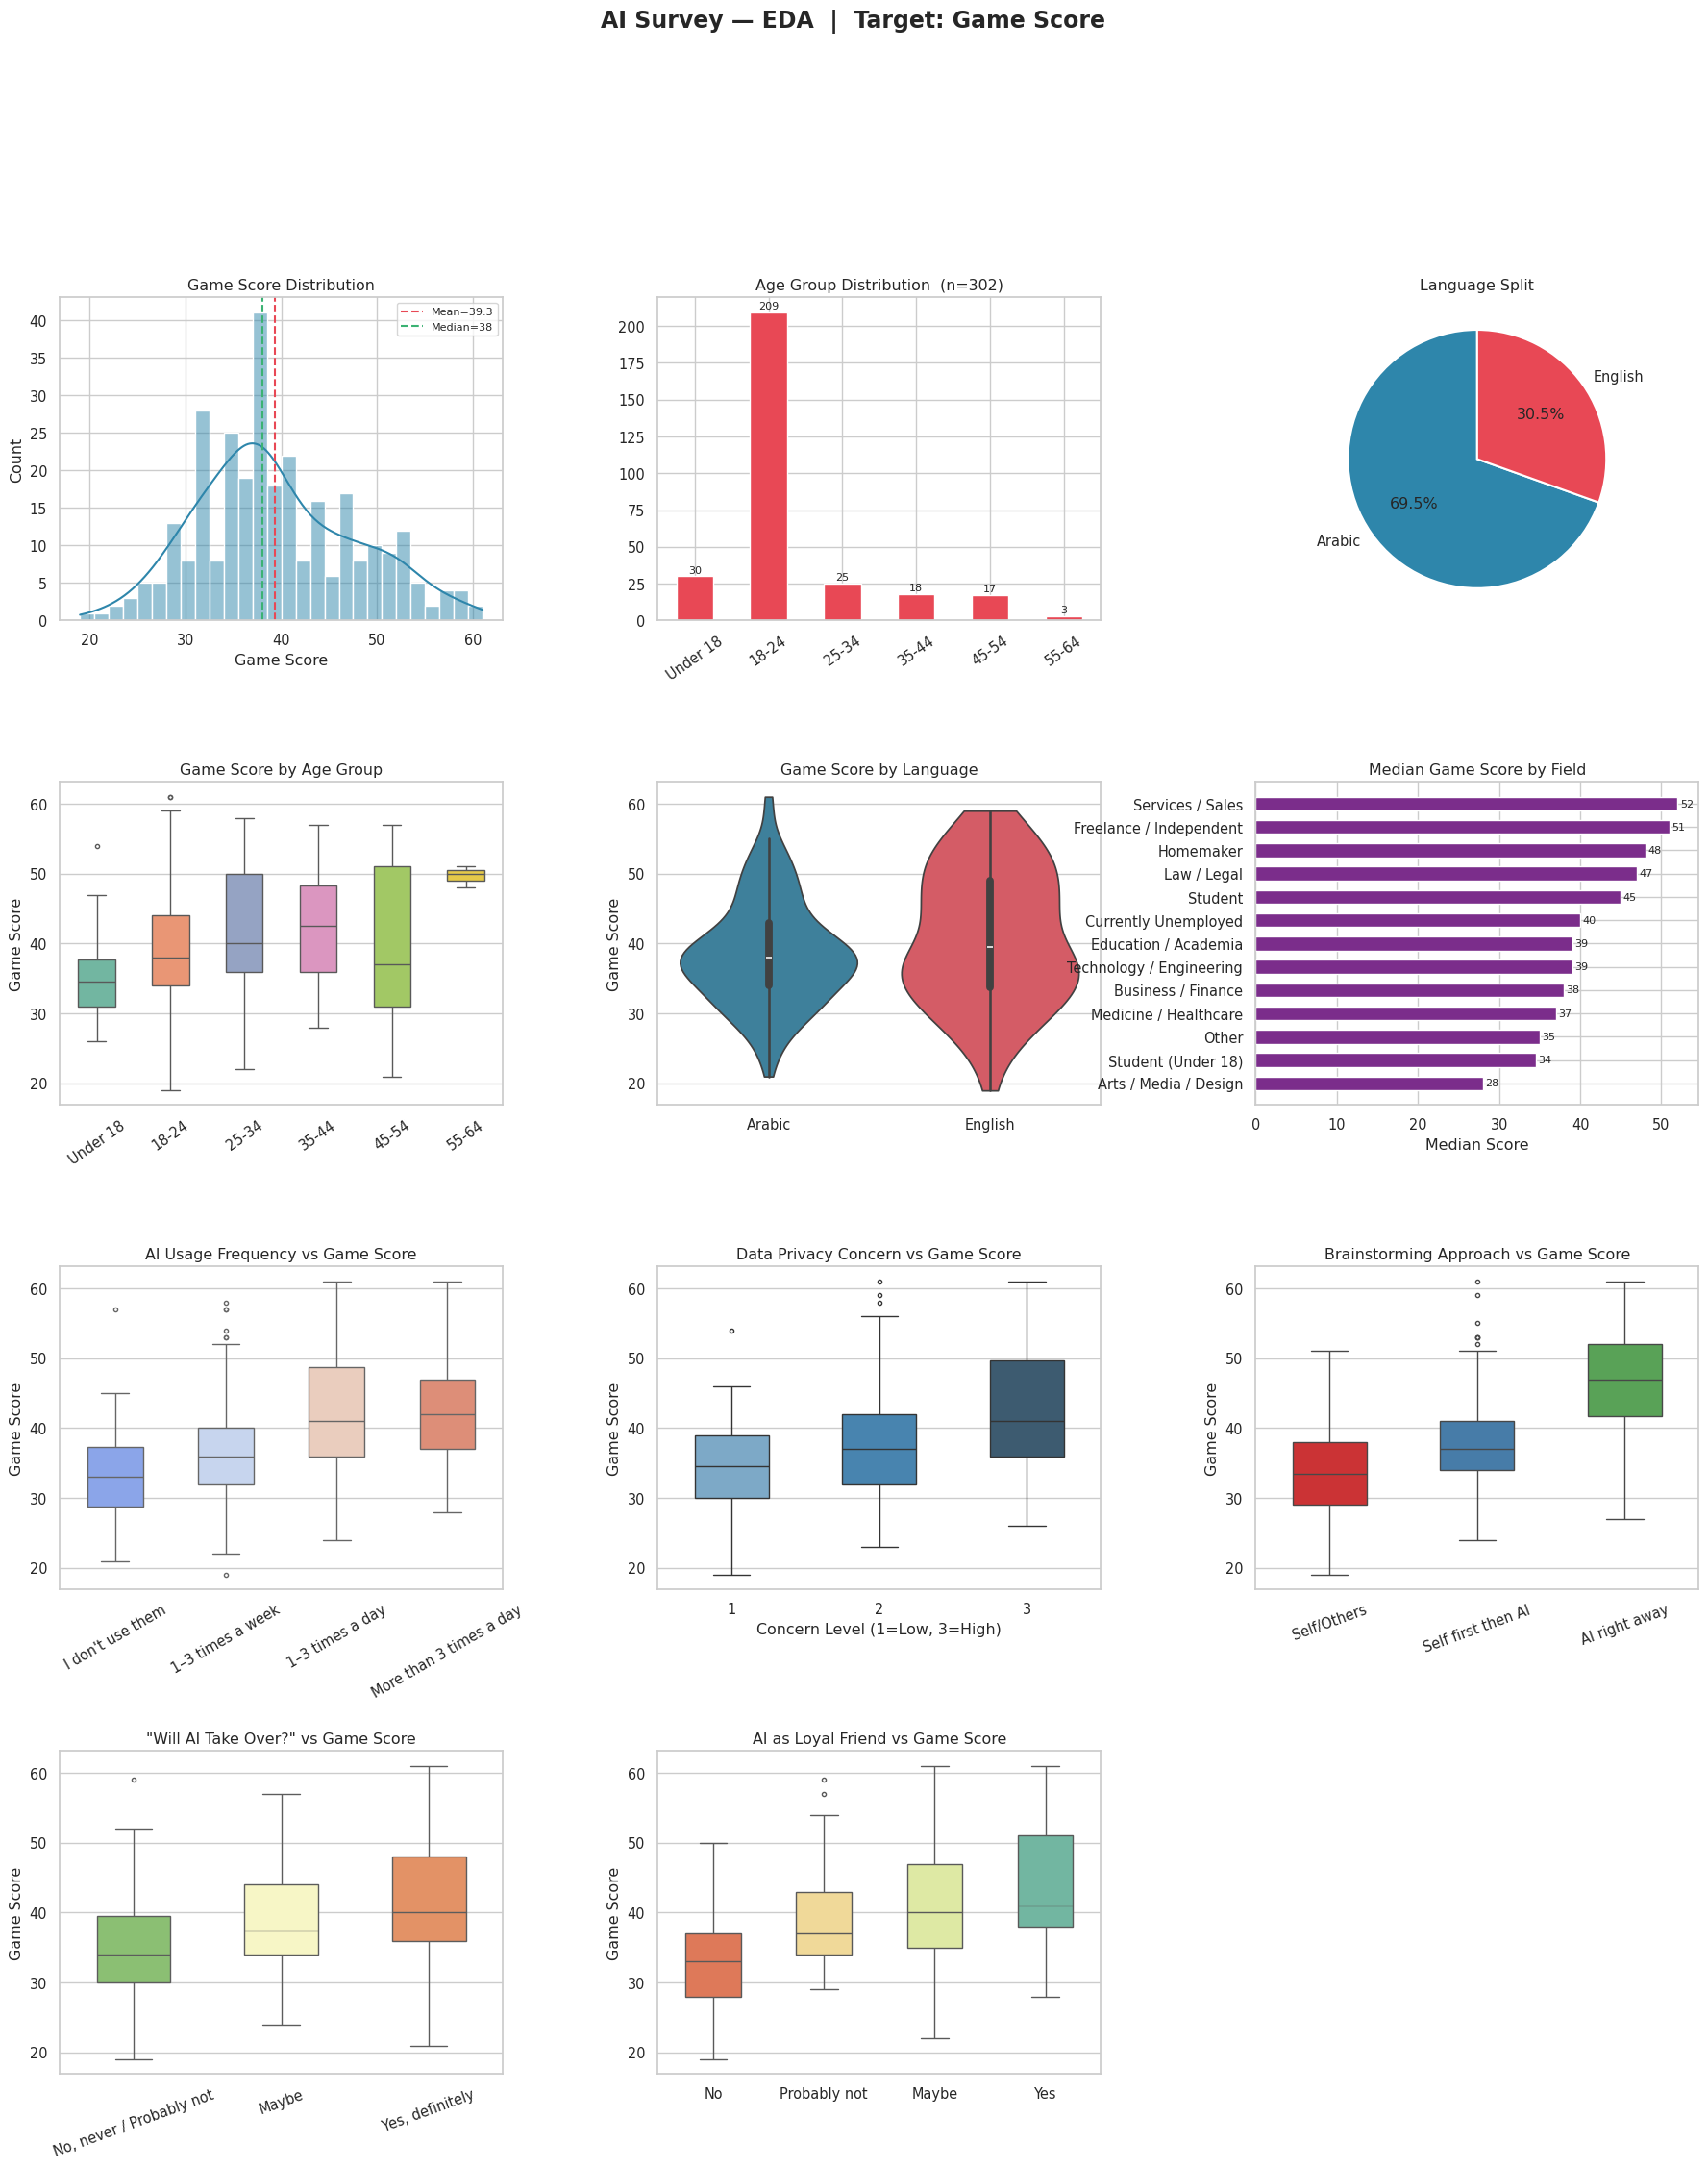

In [ ]:
# ════════════════════════════════════════════════════════════
# 5. EDA — VISUAL DASHBOARD
# ════════════════════════════════════════════════════════════
sns.set_theme(style='whitegrid', palette='muted', font_scale=0.95)
BLUE   = '#2E86AB'
CORAL  = '#E84855'
GREEN  = '#3BB273'
PURPLE = '#7B2D8B'

fig = plt.figure(figsize=(22, 24))
fig.suptitle('AI Survey — EDA  |  Target: Game Score',
             fontsize=17, fontweight='bold', y=1.005)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.50, wspace=0.35)

# 1. Target distribution
ax = fig.add_subplot(gs[0, 0])
sns.histplot(df_raw[TARGET], bins=28, kde=True, color=BLUE, ax=ax, edgecolor='white')
ax.axvline(df_raw[TARGET].mean(), color=CORAL, ls='--', lw=1.5, label=f'Mean={df_raw[TARGET].mean():.1f}')
ax.axvline(df_raw[TARGET].median(), color=GREEN, ls='--', lw=1.5, label=f'Median={df_raw[TARGET].median():.0f}')
ax.legend(fontsize=8)
ax.set_title('Game Score Distribution')
ax.set_xlabel('Game Score')

# 2. Age Group counts
ax = fig.add_subplot(gs[0, 1])
age_order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64']
counts = df_raw['Age Group'].value_counts().reindex(age_order, fill_value=0)
counts.plot(kind='bar', ax=ax, color=CORAL, edgecolor='white')
ax.set_title('Age Group Distribution  (n=302)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=35)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x()+p.get_width()/2, p.get_height()+1),
                ha='center', va='bottom', fontsize=8)

# 3. Language split
ax = fig.add_subplot(gs[0, 2])
lang_cnt = df_raw['Language'].value_counts()
wedges, texts, autotexts = ax.pie(lang_cnt, labels=lang_cnt.index,
    autopct='%1.1f%%', colors=[BLUE, CORAL], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Language Split')

# 4. Game Score by Age Group
ax = fig.add_subplot(gs[1, 0])
order_present = [a for a in age_order if a in df_raw['Age Group'].unique()]
sns.boxplot(data=df_raw, x='Age Group', y=TARGET, order=order_present,
            palette='Set2', ax=ax, width=0.5, fliersize=3)
ax.set_title('Game Score by Age Group')
ax.tick_params(axis='x', rotation=35)
ax.set_xlabel('')

# 5. Game Score by Language
ax = fig.add_subplot(gs[1, 1])
sns.violinplot(data=df_raw, x='Language', y=TARGET, palette=[BLUE, CORAL],
               ax=ax, inner='box', cut=0)
ax.set_title('Game Score by Language')
ax.set_xlabel('')

# 6. Median Game Score by Field
ax = fig.add_subplot(gs[1, 2])
field_med = df_raw.groupby('Field')[TARGET].median().sort_values()
bars = ax.barh(field_med.index, field_med.values, color=PURPLE, edgecolor='white', height=0.6)
for b in bars:
    ax.text(b.get_width()+0.3, b.get_y()+b.get_height()/2,
            f'{b.get_width():.0f}', va='center', fontsize=8)
ax.set_title('Median Game Score by Field')
ax.set_xlabel('Median Score')

# 7. AI Usage Frequency vs Game Score
ax = fig.add_subplot(gs[2, 0])
q1_order = ["I don't use them", '1–3 times a week',
            '1–3 times a day', 'More than 3 times a day']
q1_pres = [q for q in q1_order if q in df_raw['Q1: AI Usage Freq'].unique()]
sns.boxplot(data=df_raw, x='Q1: AI Usage Freq', y=TARGET, order=q1_pres,
            palette='coolwarm', ax=ax, width=0.5, fliersize=3)
ax.set_title('AI Usage Frequency vs Game Score')
ax.tick_params(axis='x', rotation=30)
ax.set_xlabel('')

# 8. Q9 Data Privacy vs Game Score
ax = fig.add_subplot(gs[2, 1])
sns.boxplot(data=df_raw, x='Q9: Data Privacy Concern', y=TARGET,
            palette='Blues_d', ax=ax, width=0.5, fliersize=3)
ax.set_title('Data Privacy Concern vs Game Score')
ax.set_xlabel('Concern Level (1=Low, 3=High)')

# 9. Q5 Brainstorming vs Game Score
ax = fig.add_subplot(gs[2, 2])
bs_order = ['I think it through myself, or I might ask someone who could help',
            'I think about it, then I might ask AI for ideas if I get stuck',
            'I ask AI for ideas right away']
bs_labels = ['Self/Others', 'Self first then AI', 'AI right away']
tmp = df_raw.copy()
tmp['Q5_short'] = tmp['Q5: Brainstorming'].map(dict(zip(bs_order, bs_labels)))
sns.boxplot(data=tmp, x='Q5_short', y=TARGET, palette='Set1',
            order=bs_labels, ax=ax, width=0.5, fliersize=3)
ax.set_title('Brainstorming Approach vs Game Score')
ax.tick_params(axis='x', rotation=20)
ax.set_xlabel('')

# 10. Q11 AI Takes Over vs Game Score
ax = fig.add_subplot(gs[3, 0])
q11_order = ['No, never / Probably not', 'Maybe', 'Yes, definitely']
sns.boxplot(data=df_raw, x='Q11: AI Takes Over', y=TARGET, order=q11_order,
            palette='RdYlGn_r', ax=ax, width=0.5, fliersize=3)
ax.set_title('"Will AI Take Over?" vs Game Score')
ax.tick_params(axis='x', rotation=20)
ax.set_xlabel('')

# 11. Q16 AI Loyal Friend vs Game Score
ax = fig.add_subplot(gs[3, 1])
q16_order = ['No, never', 'Probably not', 'Maybe, it sounds interesting', 'Yes, definitely']
q16_labels = ['No', 'Probably not', 'Maybe', 'Yes']
tmp2 = df_raw.copy()
tmp2['Q16_short'] = tmp2['Q16: AI Loyal Friend'].map(dict(zip(q16_order, q16_labels)))
sns.boxplot(data=tmp2, x='Q16_short', y=TARGET, order=q16_labels,
            palette='Spectral', ax=ax, width=0.5, fliersize=3)
ax.set_title('AI as Loyal Friend vs Game Score')
ax.set_xlabel('')


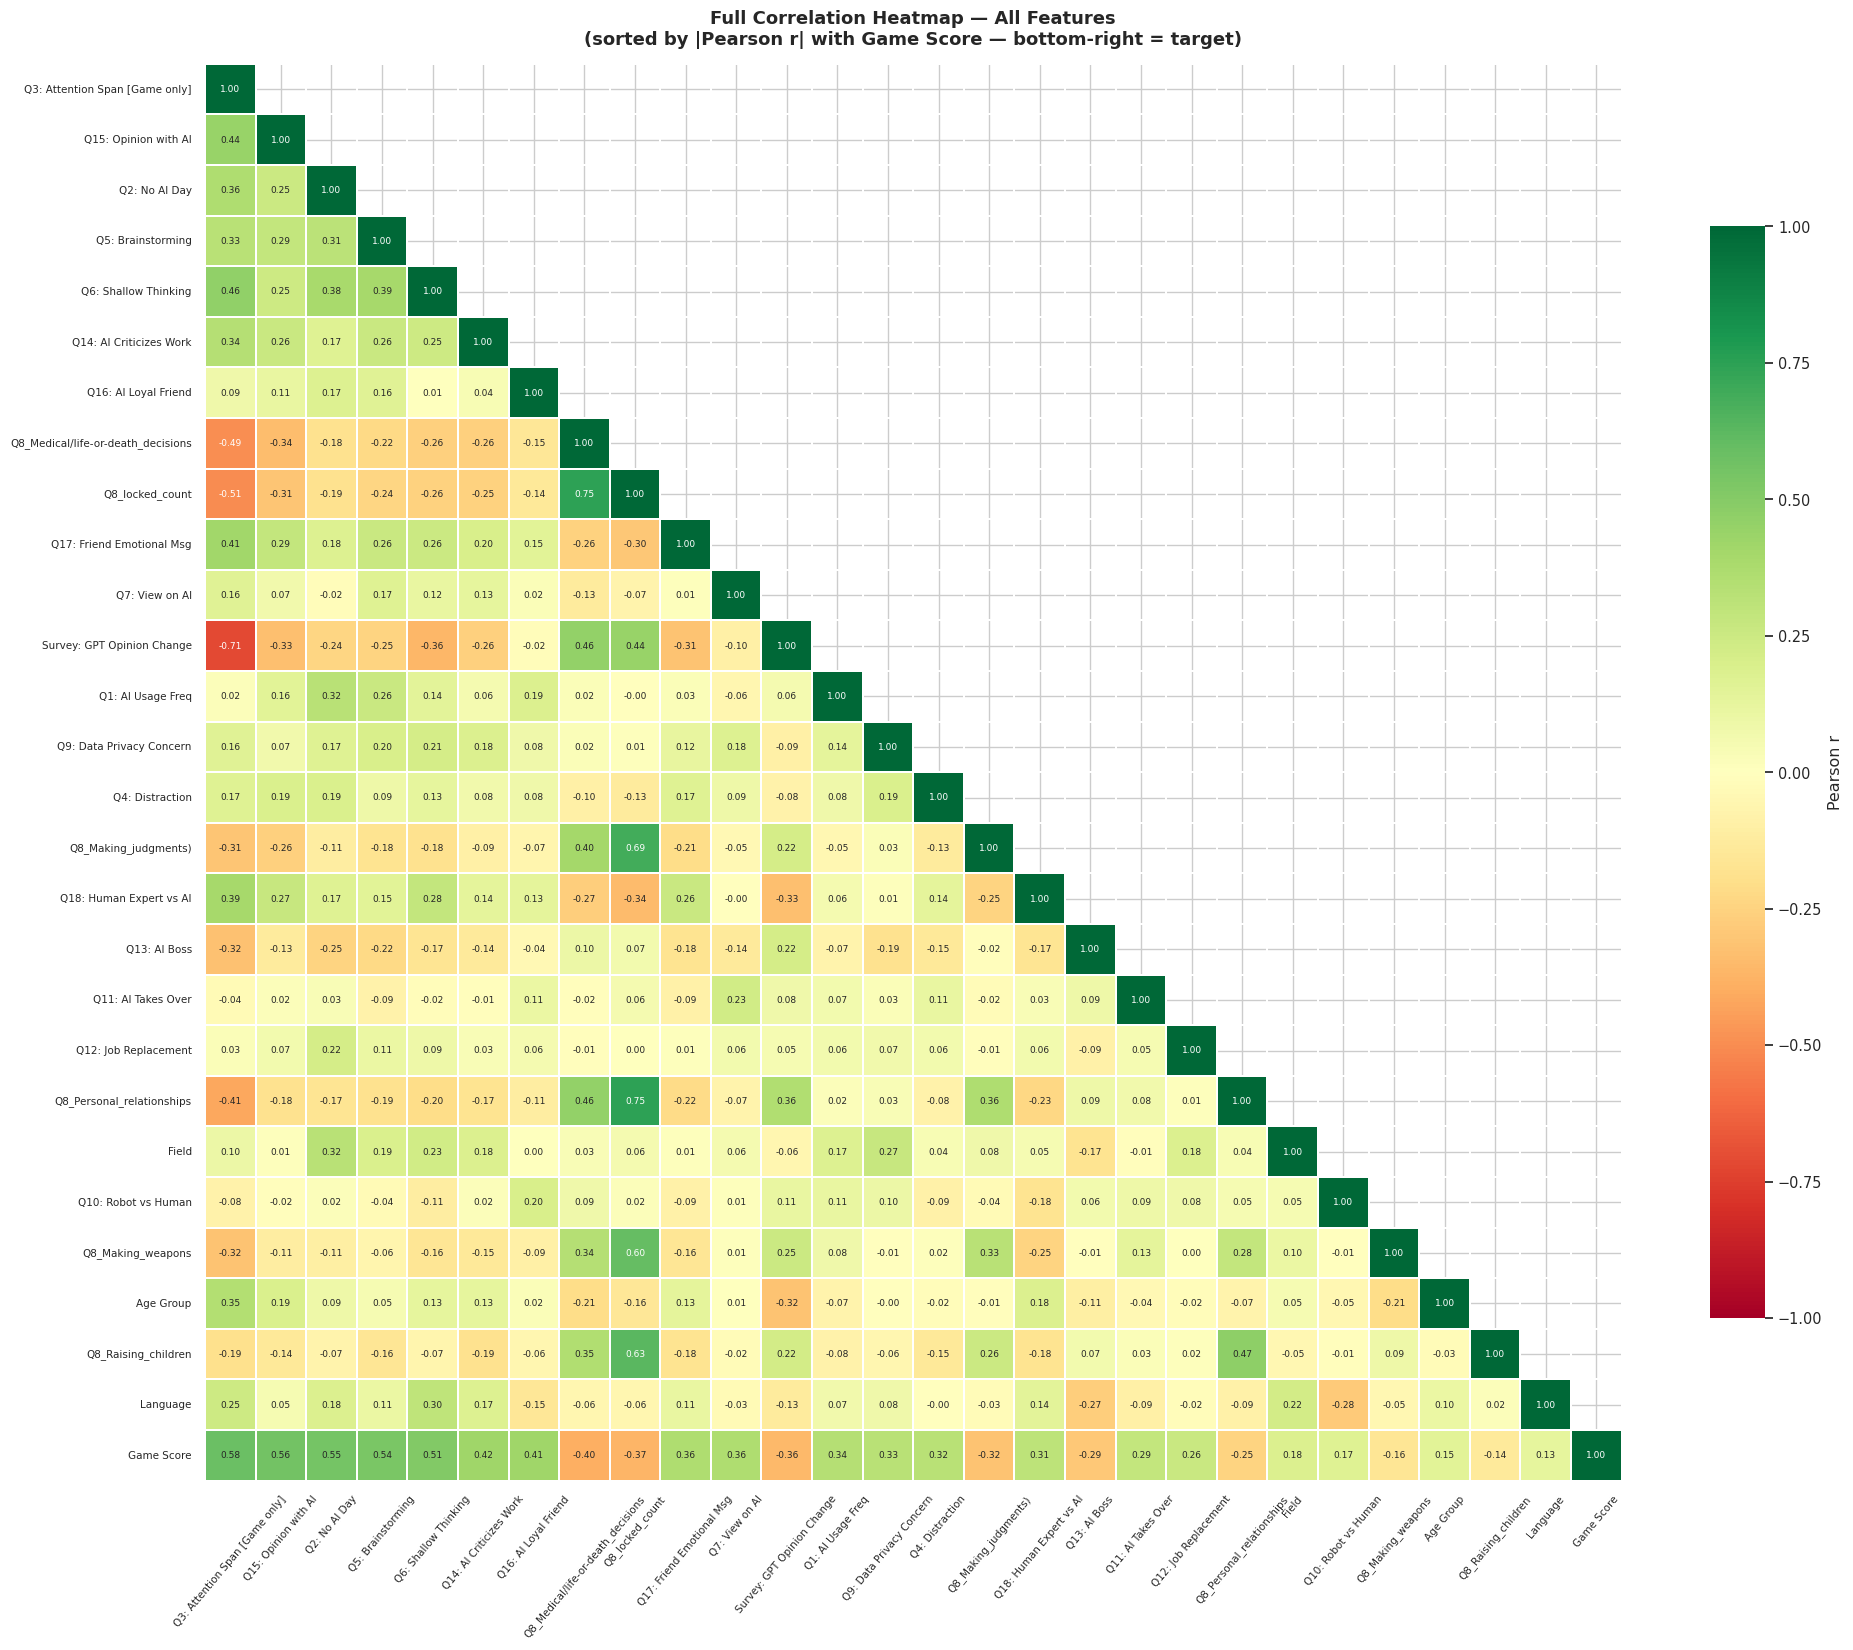

In [ ]:
# ════════════════════════════════════════════════════════════
# 6. FULL CORRELATION HEATMAP
# ════════════════════════════════════════════════════════════
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# Sort ALL features by absolute correlation with target
target_corr = (
    corr[TARGET].drop(TARGET)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)
sorted_cols  = target_corr.index.tolist() + [TARGET]
corr_sorted  = corr.loc[sorted_cols, sorted_cols]

# Lower-triangle mask
mask = np.triu(np.ones_like(corr_sorted, dtype=bool), k=1)

fig2, ax2 = plt.subplots(figsize=(20, 18))
sns.heatmap(
    corr_sorted,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.35, linecolor='white',
    annot_kws={'size': 6.5},
    square=True,
    cbar_kws={'shrink': 0.65, 'label': 'Pearson r'},
    ax=ax2
)
ax2.set_title(
    'Full Correlation Heatmap — All Features\n'
    '(sorted by |Pearson r| with Game Score — bottom-right = target)',
    fontsize=13, fontweight='bold', pad=14
)
ax2.tick_params(axis='x', rotation=50, labelsize=7.5)
ax2.tick_params(axis='y', rotation=0,  labelsize=7.5)
plt.tight_layout()



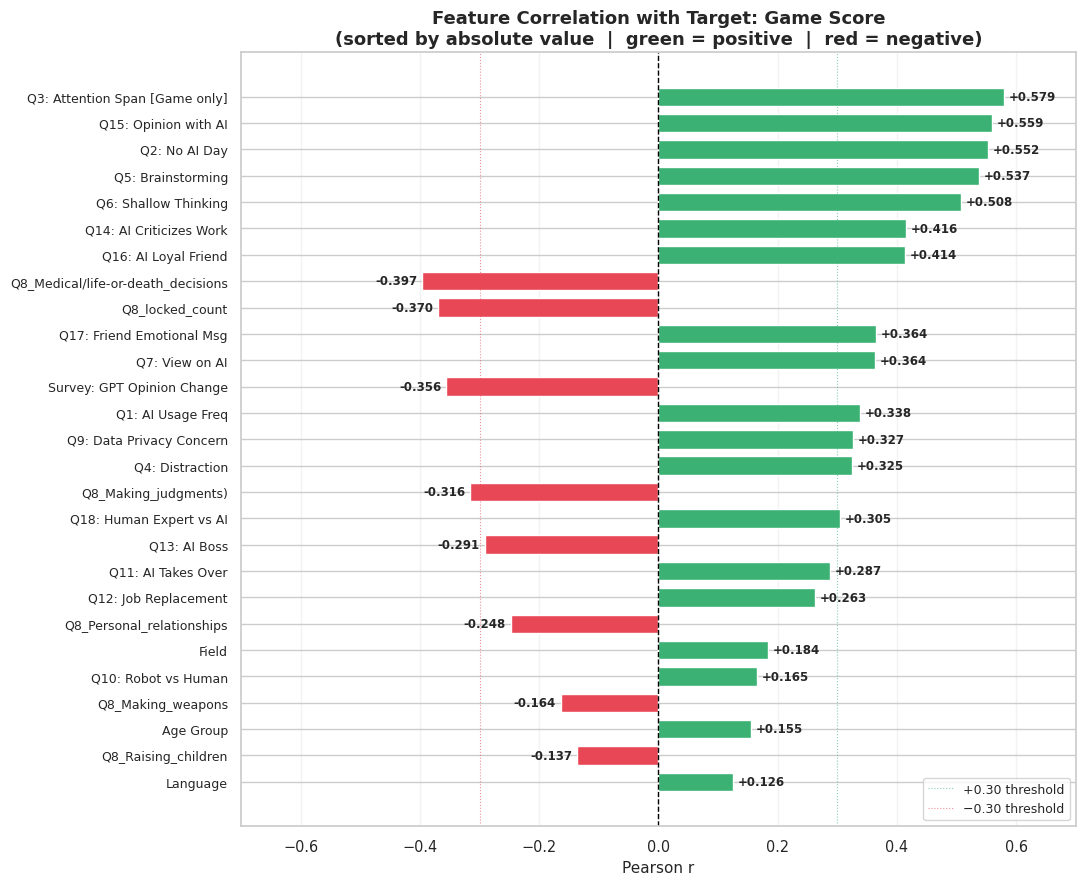

In [ ]:
# ════════════════════════════════════════════════════════════
# 7. TARGET CORRELATION BAR CHART
# ════════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(11, 9))

colors = [GREEN if v > 0 else CORAL for v in target_corr.values[::-1]]
bars   = ax3.barh(
    range(len(target_corr)),
    target_corr.values[::-1],
    color=colors, edgecolor='white', height=0.70
)
ax3.set_yticks(range(len(target_corr)))
ax3.set_yticklabels(target_corr.index[::-1], fontsize=9)

for bar, val in zip(bars, target_corr.values[::-1]):
    offset = 0.008 if val >= 0 else -0.008
    ha     = 'left'  if val >= 0 else 'right'
    ax3.text(val + offset, bar.get_y() + bar.get_height()/2,
             f'{val:+.3f}', va='center', ha=ha, fontsize=8.5, fontweight='bold')

ax3.axvline(0, color='black', lw=1.0, ls='--')
ax3.axvline( 0.3, color=GREEN, lw=0.8, ls=':', alpha=0.6, label='+0.30 threshold')
ax3.axvline(-0.3, color=CORAL, lw=0.8, ls=':', alpha=0.6, label='−0.30 threshold')
ax3.set_xlim(-0.7, 0.7)
ax3.set_xlabel('Pearson r', fontsize=11)
ax3.set_title(
    f'Feature Correlation with Target: {TARGET}\n'
    '(sorted by absolute value  |  green = positive  |  red = negative)',
    fontsize=13, fontweight='bold'
)
ax3.legend(fontsize=9, loc='lower right')
ax3.grid(axis='x', alpha=0.25)
plt.tight_layout()



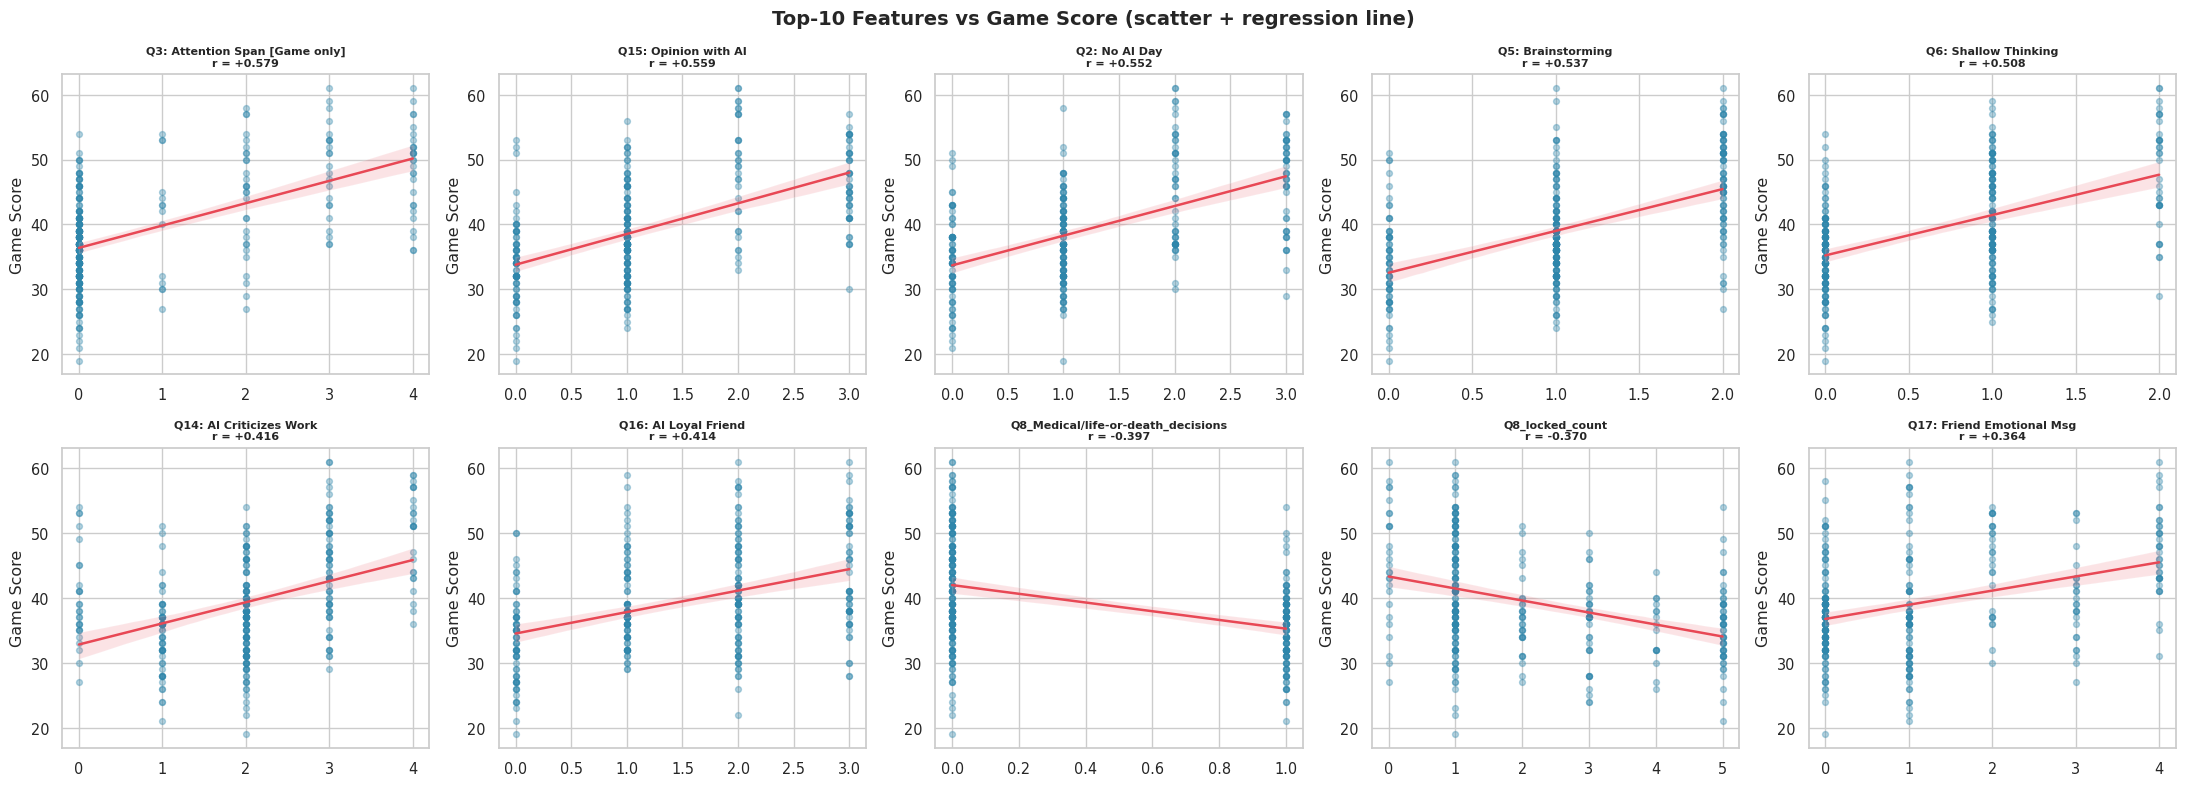

In [ ]:
# ════════════════════════════════════════════════════════════
# 8. TOP-10 FEATURE SCATTER PLOTS
# ════════════════════════════════════════════════════════════
top10 = target_corr.head(10).index.tolist()
fig4, axes = plt.subplots(2, 5, figsize=(22, 8))
fig4.suptitle('Top-10 Features vs Game Score (scatter + regression line)',
              fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, top10):
    r = target_corr[col]
    sns.regplot(data=df, x=col, y=TARGET, ax=ax,
                scatter_kws={'alpha': 0.35, 'color': BLUE, 's': 18},
                line_kws={'color': CORAL, 'lw': 1.8})
    ax.set_title(f'{col}\nr = {r:+.3f}', fontsize=8, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()

In [ ]:
# ════════════════════════════════════════════════════════════
# 9. SAVE ENCODED DATASET
# ════════════════════════════════════════════════════════════
df.to_excel(r'AI_Survey_Encoded_READY.xlsx', index=False)
print("Encoded dataset saved")

# ════════════════════════════════════════════════════════════
# 10. PRINT FULL CORRELATION RANKING
# ════════════════════════════════════════════════════════════
print("\n")
print("=" * 65)
print("  FULL CORRELATION RANKING WITH GAME SCORE")
print("=" * 65)
print(f"{'Rank':<5} {'Feature':<45} {'r':>8}  {'|r|':>6}")
print("-" * 65)
for rank, (feat, val) in enumerate(target_corr.items(), 1):
    marker = " STRONG" if abs(val) >= 0.3 else ""
    print(f"{rank:<5} {feat:<45} {val:>+8.4f}  {abs(val):>6.4f}{marker}")

print("\nAll done")


Encoded dataset saved


  FULL CORRELATION RANKING WITH GAME SCORE
Rank  Feature                                              r     |r|
-----------------------------------------------------------------
1     Q3: Attention Span [Game only]                 +0.5788  0.5788 STRONG
2     Q15: Opinion with AI                           +0.5588  0.5588 STRONG
3     Q2: No AI Day                                  +0.5522  0.5522 STRONG
4     Q5: Brainstorming                              +0.5371  0.5371 STRONG
5     Q6: Shallow Thinking                           +0.5079  0.5079 STRONG
6     Q14: AI Criticizes Work                        +0.4155  0.4155 STRONG
7     Q16: AI Loyal Friend                           +0.4142  0.4142 STRONG
8     Q8_Medical/life-or-death_decisions             -0.3965  0.3965 STRONG
9     Q8_locked_count                                -0.3702  0.3702 STRONG
10    Q17: Friend Emotional Msg                      +0.3641  0.3641 STRONG
11    Q7: View on AI                  

In [ ]:
# ============================================
# split the data
# ============================================

X = df[['Q15: Opinion with AI',
        'Q2: No AI Day',
        'Q5: Brainstorming',
        'Q6: Shallow Thinking']]
y =df['Game Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [ ]:
# ============================================
# 11. Pipeline
# ============================================

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror',
        eval_metric='rmse'
    ))
])

# ============================================
# 12. Randomized Search Parameters
# ============================================

param_distributions = {
    'xgb__n_estimators':     randint(50, 400),
    'xgb__max_depth':        randint(3, 12),
    'xgb__learning_rate':    uniform(0.01, 0.3),
    'xgb__subsample':        uniform(0.5, 0.5),
    'xgb__colsample_bytree': uniform(0.4, 0.6),
    'xgb__min_child_weight': randint(1, 10),
    'xgb__gamma':            uniform(0, 0.5),
    'xgb__reg_alpha':        uniform(0, 1.0),
    'xgb__reg_lambda':       uniform(0.5, 2.0),
}

In [ ]:
# ============================================
# 13.Cross-Validation (K-Fold)
# ============================================

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# ============================================
# 14.RandomizedSearchCV
# ============================================

print("\n" + "="*60)
print("searching for best (XGBoost + RandomizedSearchCV)...")
print("="*60)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv_strategy,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42,
    return_train_score=True
)

random_search.fit(X_train, y_train)


searching for best (XGBoost + RandomizedSearchCV)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('xgb',
                                              XGBRegressor(base_score=None,
                                                           booster=None,
                                                           callbacks=None,
                                                           colsample_bylevel=None,
                                                           colsample_bynode=None,
                                                           colsample_bytree=None,
                                                           device=None,
                                                           early_stopping_rounds=None,
                                                           enable_categorical=False,
                                                           eval_metric='rmse',
                                                           feature_types...
                                        'xgb__reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78470086a9f0>,
                                        'xgb__reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78470086b680>,
                                        'xgb__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7846ffbcb920>},
                   random_state=42, return_train_score=True, scoring='r2',
                   verbose=2)

In [ ]:
# ============================================
# 15. best results
# ============================================

print("\n" + "="*60)
print("Best results:")
print("="*60)
print(f"Best param: {random_search.best_params_}")
print(f"Best (R²) on Validation: {random_search.best_score_:.4f}")

# ============================================
# 16. model evaluation
# ============================================

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n" + "="*60)
print("evaluate the model:")
print("="*60)
print(f"R² Score:                        {r2_score(y_test, y_pred):.4f}")
print(f"MAE (Mean Absolute Error):       {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE (Root Mean Squared Error):  {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")



Best results:
Best param: {'xgb__colsample_bytree': np.float64(0.4845545349848576), 'xgb__gamma': np.float64(0.40109849037701983), 'xgb__learning_rate': np.float64(0.032365193103931246), 'xgb__max_depth': 9, 'xgb__min_child_weight': 9, 'xgb__n_estimators': 393, 'xgb__reg_alpha': np.float64(0.3948815181755697), 'xgb__reg_lambda': np.float64(1.0869763494360762), 'xgb__subsample': np.float64(0.5070399113575422)}
Best (R²) on Validation: 0.6070

evaluate the model:
R² Score:                        0.6262
MAE (Mean Absolute Error):       4.09
RMSE (Root Mean Squared Error):  4.89


In [ ]:
# ============================================
# 17. Cross-Validation to compareson
# ============================================

print("\n" + "="*60)
print("Cross-Validation (5-Fold) results:")
print("="*60)

cv_scores = cross_val_score(best_model, X, y, cv=cv_strategy, scoring='r2')
print(f"CV R² Scores: {cv_scores}")
print(f"Mean CV R²:   {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# ============================================
# 18. Feature Importance
# ============================================

xgb_model = best_model.named_steps['xgb']
feature_importance = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("(Feature Importance):")
print("="*60)
for _, row in feature_importance.iterrows():
    bar = "*" * int(row['Importance'] * 40)
    print(f"{row['Feature']:<40} : {row['Importance']:.4f}  {bar}")

# ============================================
# 19. Baseline XGBoost
# ============================================

print("\n" + "="*60)
print("XGBoost Baseline:")
print("="*60)

baseline_xgb = XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror')
baseline_xgb.fit(X_train, y_train)
baseline_pred = baseline_xgb.predict(X_test)

baseline_r2  = r2_score(y_test, baseline_pred)
optimized_r2 = r2_score(y_test, y_pred)

print(f"Baseline R²:  {baseline_r2:.4f}")
print(f"Optimized R²: {optimized_r2:.4f}")
print(f"Optimal:       {optimized_r2 - baseline_r2:+.4f}")



Cross-Validation (5-Fold) results:
CV R² Scores: [0.63398856 0.65416592 0.59791398 0.69223285 0.56679296]
Mean CV R²:   0.6290 (+/- 0.0871)

(Feature Importance):
Q15: Opinion with AI                     : 0.2701  **********
Q5: Brainstorming                        : 0.2536  **********
Q6: Shallow Thinking                     : 0.2514  **********
Q2: No AI Day                            : 0.2249  ********

XGBoost Baseline:
Baseline R²:  0.3225
Optimized R²: 0.6262
Optimal:       +0.3038


In [ ]:
# Save model
joblib.dump(best_model, 'best_xgboost_rsearch.pkl')
print("\nModel saved to: best_xgboost_rsearch.pkl")

# Save RandomizedSearchCV object
joblib.dump(random_search, 'random_search_xgb.pkl')
print("RandomizedSearchCV saved to: random_search_xgb.pkl")

# Save search results
results_df = pd.DataFrame(random_search.cv_results_)
results_df.to_csv('xgboost_search_results.csv', index=False)
print("Search results saved to: xgboost_search_results.csv")

print("\n" + "="*60)
print("Training and tuning completed using XGBoost + RandomizedSearchCV!")
print("="*60)


Model saved to: best_xgboost_rsearch.pkl
RandomizedSearchCV saved to: random_search_xgb.pkl
Search results saved to: xgboost_search_results.csv

Training and tuning completed using XGBoost + RandomizedSearchCV!


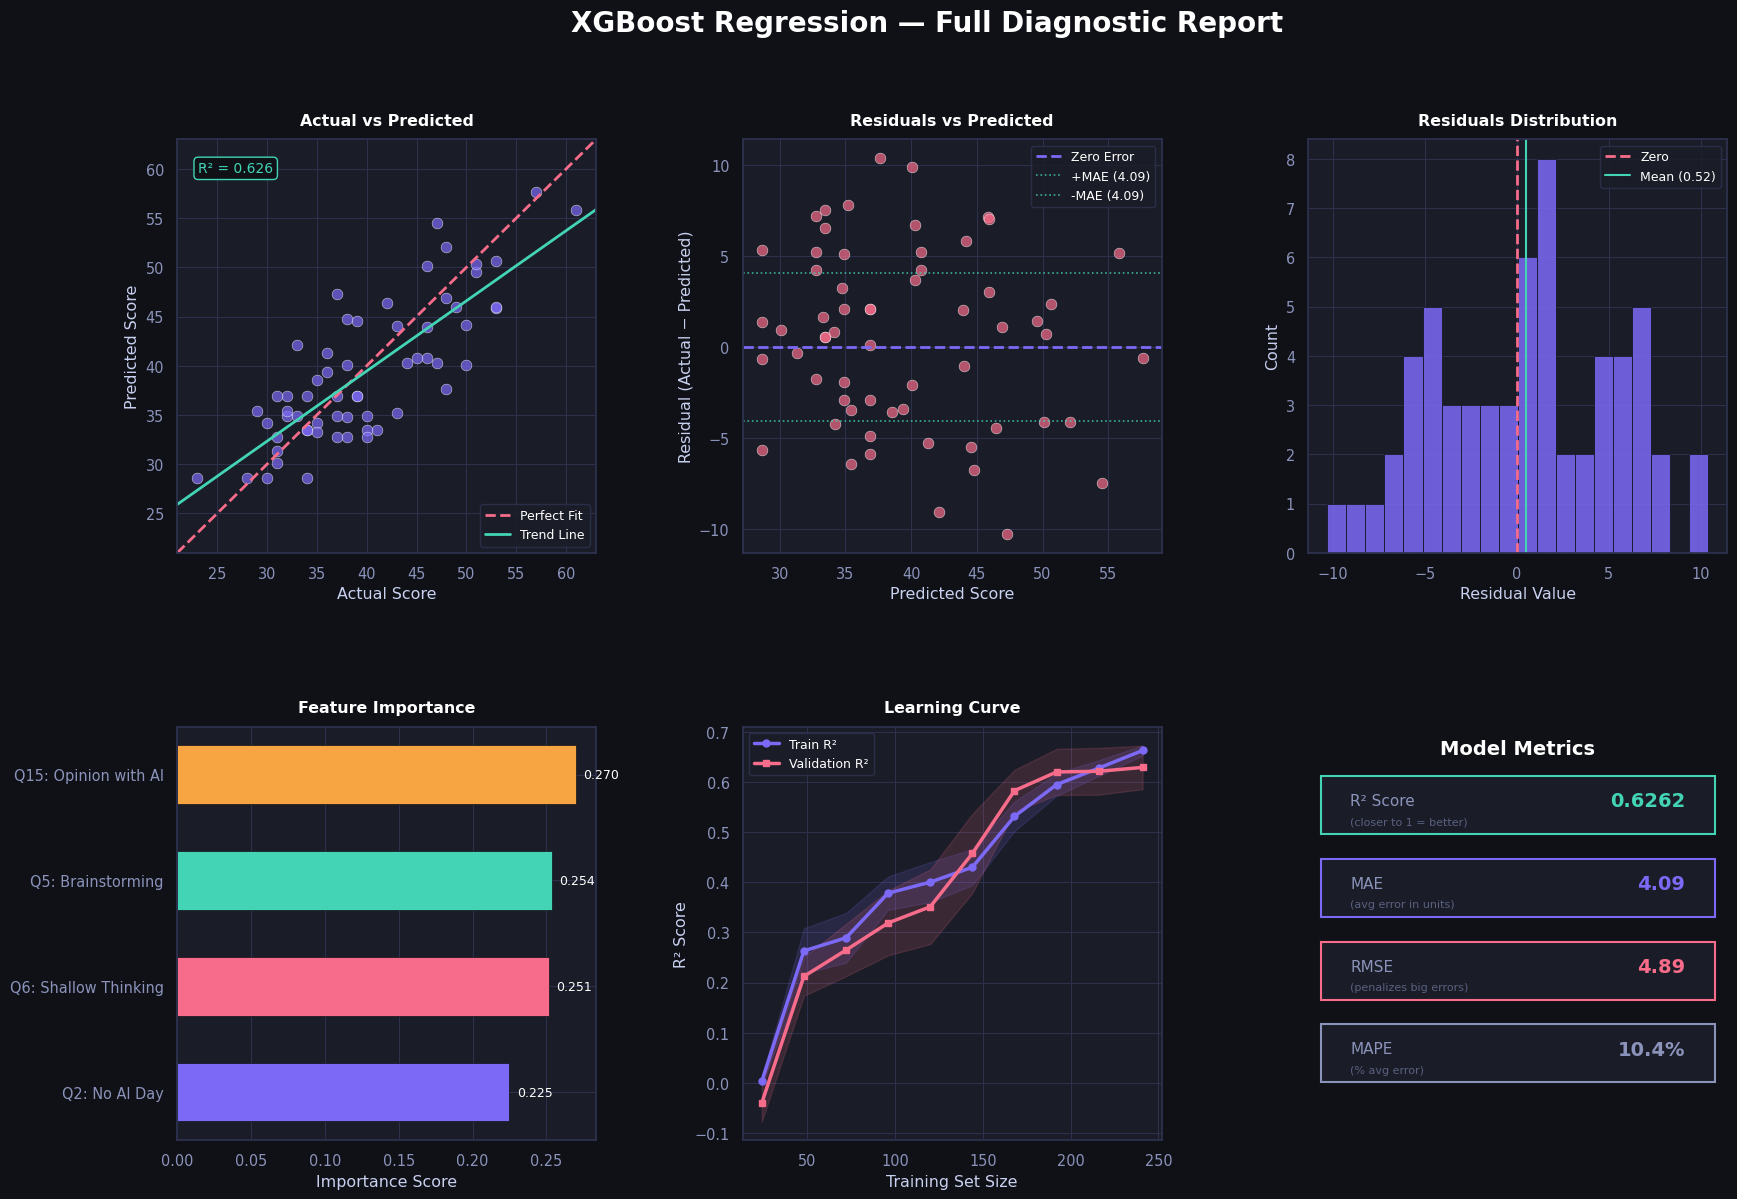

Saved to: xgboost_diagnostic_report.png


In [ ]:
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c9d1f0',
    'xtick.color':      '#8b93ba',
    'ytick.color':      '#8b93ba',
    'text.color':       '#c9d1f0',
    'grid.color':       '#2e3250',
    'grid.linewidth':   0.7,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

ACCENT   = '#7c6af7'
ACCENT2  = '#f76c8a'
ACCENT3  = '#43d4b5'
NEUTRAL  = '#8b93ba'

# ============================================
# Load model and data
# ============================================

best_model = joblib.load('best_xgboost_rsearch.pkl')

y_pred      = best_model.predict(X_test)
residuals   = y_test - y_pred

# ============================================
# Figure(2×3 grid)
# ============================================

fig = plt.figure(figsize=(20, 13), facecolor='#0f1117')
fig.suptitle(
    'XGBoost Regression — Full Diagnostic Report',
    fontsize=20, fontweight='bold', color='white', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# Plot 1: Actual vs Predicted
ax1 = fig.add_subplot(gs[0, 0])

ax1.scatter(y_test, y_pred, color=ACCENT, alpha=0.7, s=60, edgecolors='white', linewidths=0.4)

# perfect prediction
lims = [min(y_test.min(), y_pred.min()) - 2, max(y_test.max(), y_pred.max()) + 2]
ax1.plot(lims, lims, color=ACCENT2, linewidth=2, linestyle='--', label='Perfect Fit')

# regression line between actual and predicted
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
x_line = np.linspace(lims[0], lims[1], 100)
ax1.plot(x_line, p(x_line), color=ACCENT3, linewidth=2, linestyle='-', label='Trend Line')

ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel('Actual Score');  ax1.set_ylabel('Predicted Score')
ax1.set_title('Actual vs Predicted', fontweight='bold', color='white', pad=10)
ax1.legend(fontsize=9, facecolor='#1a1d27', edgecolor='#2e3250', labelcolor='white')
ax1.text(0.05, 0.92, f'R² = {r2_score(y_test, y_pred):.3f}',
         transform=ax1.transAxes, fontsize=10, color=ACCENT3,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#0f1117', edgecolor=ACCENT3))
ax1.grid(True)

# Plot 2: Residuals vs Predicted
ax2 = fig.add_subplot(gs[0, 1])

ax2.scatter(y_pred, residuals, color=ACCENT2, alpha=0.7, s=60, edgecolors='white', linewidths=0.4)
ax2.axhline(0, color=ACCENT, linewidth=2, linestyle='--', label='Zero Error')

# ±1 MAE
mae = mean_absolute_error(y_test, y_pred)
ax2.axhline( mae, color=ACCENT3, linewidth=1.2, linestyle=':', alpha=0.8, label=f'+MAE ({mae:.2f})')
ax2.axhline(-mae, color=ACCENT3, linewidth=1.2, linestyle=':', alpha=0.8, label=f'-MAE ({mae:.2f})')

ax2.set_xlabel('Predicted Score'); ax2.set_ylabel('Residual (Actual − Predicted)')
ax2.set_title('Residuals vs Predicted', fontweight='bold', color='white', pad=10)
ax2.legend(fontsize=9, facecolor='#1a1d27', edgecolor='#2e3250', labelcolor='white')
ax2.grid(True)

# Plot 3: Residuals Distribution
ax3 = fig.add_subplot(gs[0, 2])

ax3.hist(residuals, bins=20, color=ACCENT, edgecolor='#0f1117', linewidth=0.6, alpha=0.85)
ax3.axvline(0,              color=ACCENT2, linewidth=2,   linestyle='--', label='Zero')
ax3.axvline(residuals.mean(), color=ACCENT3, linewidth=1.5, linestyle='-',  label=f'Mean ({residuals.mean():.2f})')

ax3.set_xlabel('Residual Value'); ax3.set_ylabel('Count')
ax3.set_title('Residuals Distribution', fontweight='bold', color='white', pad=10)
ax3.legend(fontsize=9, facecolor='#1a1d27', edgecolor='#2e3250', labelcolor='white')
ax3.grid(True, axis='y')

# Plot 4: Feature Importance
ax4 = fig.add_subplot(gs[1, 0])

xgb_model        = best_model.named_steps['xgb']
importances       = xgb_model.feature_importances_
feature_names     = list(X.columns)
sorted_idx        = np.argsort(importances)
colors_bar        = [ACCENT, ACCENT2, ACCENT3, '#f7a543', '#a3f76c'][:len(feature_names)]

bars = ax4.barh(
    [feature_names[i] for i in sorted_idx],
    importances[sorted_idx],
    color=[colors_bar[i % len(colors_bar)] for i in range(len(sorted_idx))],
    edgecolor='#0f1117', linewidth=0.5, height=0.55
)
for bar, val in zip(bars, importances[sorted_idx]):
    ax4.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9, color='white')

ax4.set_xlabel('Importance Score')
ax4.set_title('Feature Importance', fontweight='bold', color='white', pad=10)
ax4.grid(True, axis='x')

# Plot 5: Learning Curve
ax5 = fig.add_subplot(gs[1, 1])

cv_lc = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y,
    cv=cv_lc,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

ax5.plot(train_sizes, train_mean, color=ACCENT,  linewidth=2.5, marker='o', markersize=5, label='Train R²')
ax5.plot(train_sizes, val_mean,   color=ACCENT2, linewidth=2.5, marker='s', markersize=5, label='Validation R²')
ax5.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=ACCENT)
ax5.fill_between(train_sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.15, color=ACCENT2)

ax5.set_xlabel('Training Set Size'); ax5.set_ylabel('R² Score')
ax5.set_title('Learning Curve', fontweight='bold', color='white', pad=10)
ax5.legend(fontsize=9, facecolor='#1a1d27', edgecolor='#2e3250', labelcolor='white')
ax5.grid(True)

# Plot 6: Metrics Summary Card
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / np.where(y_test == 0, 1, y_test))) * 100

metrics = [
    ('R² Score',  f'{r2:.4f}',   ACCENT3,  '(closer to 1 = better)'),
    ('MAE',       f'{mae:.2f}',  ACCENT,   '(avg error in units)'),
    ('RMSE',      f'{rmse:.2f}', ACCENT2,  '(penalizes big errors)'),
    ('MAPE',      f'{mape:.1f}%',NEUTRAL,  '(% avg error)'),
]

ax6.text(0.5, 0.97, 'Model Metrics', ha='center', va='top',
         fontsize=14, fontweight='bold', color='white', transform=ax6.transAxes)

for i, (label, value, color, note) in enumerate(metrics):
    y_pos = 0.80 - i * 0.20
    ax6.add_patch(plt.Rectangle((0.03, y_pos - 0.06), 0.94, 0.14,
                                 facecolor='#1a1d27', edgecolor=color,
                                 linewidth=1.5, transform=ax6.transAxes))
    ax6.text(0.10, y_pos + 0.02, label, ha='left', va='center',
             fontsize=11, color=NEUTRAL, transform=ax6.transAxes)
    ax6.text(0.90, y_pos + 0.02, value, ha='right', va='center',
             fontsize=14, fontweight='bold', color=color, transform=ax6.transAxes)
    ax6.text(0.10, y_pos - 0.03, note, ha='left', va='center',
             fontsize=8, color='#5a6080', transform=ax6.transAxes)

plt.savefig('xgboost_diagnostic_report.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Saved to: xgboost_diagnostic_report.png")

In [ ]:
# ============================================
# Classification
# ============================================
def score_to_level(score):
    if score < 30:
        return 'Low'
    elif score <= 40:
        return 'Medium'
    else:
        return 'High'

df['Score_Level'] = df['Game Score'].apply(score_to_level)

feature_cols = [col for col in df.columns if col not in ['Game Score', 'Score_Level']]
X = df[feature_cols]
y = df['Score_Level']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.86      0.83      0.84        23
         Low       1.00      0.50      0.67         6
      Medium       0.81      0.91      0.85        32

    accuracy                           0.84        61
   macro avg       0.89      0.74      0.79        61
weighted avg       0.85      0.84      0.83        61

Confusion Matrix:
[[19  0  4]
 [ 0  3  3]
 [ 3  0 29]]


# NLP on Q19 Open: Life without AI column:

## NLP Text Preprocessing Flow

1. Detect language (Arabic, English, or Mixed)
2. Normalize Arabic text (unify letters, remove diacritics, etc.)
3. Convert Arabic slang/dialect to Modern Standard Arabic
4. Translate Arabic content to English
5. Handle mixed-language text by extracting and translating Arabic parts
6. Merge all samples into a single English corpus
7. Apply standard English preprocessing (lowercasing, punctuation removal, tokenization, etc.)

In [ ]:
# on the terminal to install the required libaries:

# !pip install langdetect

# !pip install emoji

# !pip install transformers sentencepiece torch

# !pip install contractions

# !pip install sentence-transformers

# !pip install imbalanced-learn

In [ ]:
## 1. detect language in text
#from langdetect import detect, DetectorFactory
import re


def simple_lang_detect(text):
    if pd.isna(text):
        return 0, ["no text"]

    text = str(text).strip().lower()

    if len(text) == 0:
        return 0, ["no text"]

    arabic_chars = len(re.findall(r'[\u0600-\u06FF]', text))
    english_chars = len(re.findall(r'[a-z]', text))

    if arabic_chars == 0 and english_chars == 0:
        return 0, ["no text"]

    if arabic_chars > 0 and english_chars > 0:
        return 2, ["mixed"]
    elif arabic_chars > 0:
        return 1, ["ar"]
    else:
        return 1, ["en"]

In [ ]:
def light_preprocess(text):
    if pd.isna(text):
        return ""
    return str(text).strip()

df_NLP = df_raw[['Q19 Open: Life without AI']].copy()

df_NLP['clean_text'] = df_NLP['Q19 Open: Life without AI'].apply(light_preprocess)

df_NLP[['lang_count', 'languages_used']] = df_NLP['clean_text'].apply(
    lambda x: pd.Series(simple_lang_detect(x))
)

In [ ]:
df_NLP['languages_used'].value_counts()

,count
languages_used,
[ar],201
[en],87
[no text],14


In [ ]:
df_NLP

,Q19 Open: Life without AI,clean_text,lang_count,languages_used
0,تعديل الصور,تعديل الصور,1,[ar]
1,سرعة البحث,سرعة البحث,1,[ar]
2,هاخد وقت في مذاكرة وفهم دروس وغيره,هاخد وقت في مذاكرة وفهم دروس وغيره,1,[ar]
3,الوصول لمصادر المعلومات هيكون صعب,الوصول لمصادر المعلومات هيكون صعب,1,[ar]
4,كنت هعصر مخي لحد م اوصل للمعلومة او اسيبها خالص,كنت هعصر مخي لحد م اوصل للمعلومة او اسيبها خالص,1,[ar]
...,...,...,...,...
297,I would spend more evenings reading to stay up...,I would spend more evenings reading to stay up...,1,[en]
298,تعلم مهارات جديدة كان هيبقى اكتر تعب واكتر وقت,تعلم مهارات جديدة كان هيبقى اكتر تعب واكتر وقت,1,[ar]
299,كنت هاكون محتاج اعمل ريسيرش طويل قبل كل قرار صغير,كنت هاكون محتاج اعمل ريسيرش طويل قبل كل قرار صغير,1,[ar]
300,NaN,,0,[no text]


In [ ]:
mixed_cells = df_NLP[df_NLP['lang_count'] > 1]

print(mixed_cells)
print("Number of mixed-language cells:", len(mixed_cells))

Empty DataFrame
Columns: [Q19 Open: Life without AI, clean_text, lang_count, languages_used]
Index: []
Number of mixed-language cells: 0


##### so there is no response has more than one language.

### Normalize the arabic text

In [ ]:
## check if there is any emoji
import emoji


def contains_emoji(text):
    """
    Detect if text contains emojis using emoji library.
    """

    # Handle missing values
    if pd.isna(text):
        return False

    text = str(text)  # ensure string type

    return any(char in emoji.EMOJI_DATA for char in text)
# Apply function on a single column in DataFrame

df_NLP['has_emoji'] = df_NLP['Q19 Open: Life without AI'].apply(contains_emoji)

In [ ]:
print(df_NLP['has_emoji'].value_counts())
print(df_NLP[df_NLP['has_emoji'] == True])

has_emoji
False    301
True       1
Name: count, dtype: int64
   Q19 Open: Life without AI clean_text  lang_count languages_used  has_emoji
25                         😌          😌           0      [no text]       True


In [ ]:
df_NLP.head(30)

,Q19 Open: Life without AI,clean_text,lang_count,languages_used,has_emoji
0,تعديل الصور,تعديل الصور,1,[ar],False
1,سرعة البحث,سرعة البحث,1,[ar],False
2,هاخد وقت في مذاكرة وفهم دروس وغيره,هاخد وقت في مذاكرة وفهم دروس وغيره,1,[ar],False
3,الوصول لمصادر المعلومات هيكون صعب,الوصول لمصادر المعلومات هيكون صعب,1,[ar],False
4,كنت هعصر مخي لحد م اوصل للمعلومة او اسيبها خالص,كنت هعصر مخي لحد م اوصل للمعلومة او اسيبها خالص,1,[ar],False
5,تظبيط الصور والاسئلة الصغيره السريعة و المعلوم...,تظبيط الصور والاسئلة الصغيره السريعة و المعلوم...,1,[ar],False
6,the way i think in any problem i face would co...,the way i think in any problem i face would co...,1,[en],False
7,سرعة اداء المهام,سرعة اداء المهام,1,[ar],False
8,كان ممكن احتار الجيب المعلومة منين,كان ممكن احتار الجيب المعلومة منين,1,[ar],False
9,المذاكرة كانت حتبقى اصعب بشكل واضح,المذاكرة كانت حتبقى اصعب بشكل واضح,1,[ar],False


In [ ]:
df_NLP['Q19 Open: Life without AI'] = df_NLP['Q19 Open: Life without AI'].str.replace('😌', 'ستكون المهمات اصعب بدونه', regex=False)

df_NLP.head(30)

,Q19 Open: Life without AI,clean_text,lang_count,languages_used,has_emoji
0,تعديل الصور,تعديل الصور,1,[ar],False
1,سرعة البحث,سرعة البحث,1,[ar],False
2,هاخد وقت في مذاكرة وفهم دروس وغيره,هاخد وقت في مذاكرة وفهم دروس وغيره,1,[ar],False
3,الوصول لمصادر المعلومات هيكون صعب,الوصول لمصادر المعلومات هيكون صعب,1,[ar],False
4,كنت هعصر مخي لحد م اوصل للمعلومة او اسيبها خالص,كنت هعصر مخي لحد م اوصل للمعلومة او اسيبها خالص,1,[ar],False
5,تظبيط الصور والاسئلة الصغيره السريعة و المعلوم...,تظبيط الصور والاسئلة الصغيره السريعة و المعلوم...,1,[ar],False
6,the way i think in any problem i face would co...,the way i think in any problem i face would co...,1,[en],False
7,سرعة اداء المهام,سرعة اداء المهام,1,[ar],False
8,كان ممكن احتار الجيب المعلومة منين,كان ممكن احتار الجيب المعلومة منين,1,[ar],False
9,المذاكرة كانت حتبقى اصعب بشكل واضح,المذاكرة كانت حتبقى اصعب بشكل واضح,1,[ar],False


In [ ]:
def normalize_arabic(text):
    """
    Normalize Arabic text for NLP preprocessing.
    """

    # Remove diacritics (tashkeel)
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)

    # Normalize different forms of Alef
    text = re.sub(r'[إأآا]', 'ا', text)

    # Normalize Yeh and Teh Marbuta
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ة', 'ه', text)

    # Remove tatweel (ـ)
    text = re.sub(r'ـ', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text
df_NLP['normalized_text'] = df_NLP['Q19 Open: Life without AI'].fillna("").apply(normalize_arabic)

In [ ]:
df_NLP

,Q19 Open: Life without AI,clean_text,lang_count,languages_used,has_emoji,normalized_text
0,تعديل الصور,تعديل الصور,1,[ar],False,تعديل الصور
1,سرعة البحث,سرعة البحث,1,[ar],False,سرعه البحث
2,هاخد وقت في مذاكرة وفهم دروس وغيره,هاخد وقت في مذاكرة وفهم دروس وغيره,1,[ar],False,هاخد وقت في مذاكره وفهم دروس وغيره
3,الوصول لمصادر المعلومات هيكون صعب,الوصول لمصادر المعلومات هيكون صعب,1,[ar],False,الوصول لمصادر المعلومات هيكون صعب
4,كنت هعصر مخي لحد م اوصل للمعلومة او اسيبها خالص,كنت هعصر مخي لحد م اوصل للمعلومة او اسيبها خالص,1,[ar],False,كنت هعصر مخي لحد م اوصل للمعلومه او اسيبها خالص
...,...,...,...,...,...,...
297,I would spend more evenings reading to stay up...,I would spend more evenings reading to stay up...,1,[en],False,I would spend more evenings reading to stay up...
298,تعلم مهارات جديدة كان هيبقى اكتر تعب واكتر وقت,تعلم مهارات جديدة كان هيبقى اكتر تعب واكتر وقت,1,[ar],False,تعلم مهارات جديده كان هيبقي اكتر تعب واكتر وقت
299,كنت هاكون محتاج اعمل ريسيرش طويل قبل كل قرار صغير,كنت هاكون محتاج اعمل ريسيرش طويل قبل كل قرار صغير,1,[ar],False,كنت هاكون محتاج اعمل ريسيرش طويل قبل كل قرار صغير
300,NaN,,0,[no text],False,


#### slang replacement

In [ ]:
### first phrase slang
phrase_dict = {
    # effort / difficulty
    "هعصر مخي": "سأبذل مجهود كبير",
    "هقعد ادور": "سأبحث لفترة طويلة",
    "هحتاج وقت اطول": "سيستغرق وقت أطول",

     "هاخد وقت " : "استغرق وقت",
    # research
    "ادور علي المعلومة": "ابحث عن المعلومات",
    "الوصول للمعلومات صعب": "الوصول للمعلومات سيكون صعب",

    # dependency on AI
    "باعتمد عليه": "اعتمد على الذكاء الاصطناعي",
    "بسال شات": "استخدم الذكاء الاصطناعي",

    "اسيبها خالص" : "ساتوقف عن البحث",
    "لم يكون" : "عندما يكون",

    # no impact
    "ولا حاجه": "لا يوجد تأثير",
    "مش هيأثر": "لا تأثير"
}

phrase_dict.update({
    "هقعد ادور على": "سأبحث عن",
    "هقعد ادور علي": "سأبحث عن",
    "هحتاج وقت طويل": "سيستغرق وقت طويل"

})

def clean_before_replace(text):
    if pd.isna(text):
        return ""
    text = re.sub(r'\s+', ' ', text)  # مهم جدًا
    return text.strip()

def replace_phrases(text):
    text = clean_before_replace(text)

    for phrase, replacement in phrase_dict.items():
        pattern = re.compile(re.escape(phrase.strip()), re.IGNORECASE)
        text = pattern.sub(replacement, text)

    return text


df_NLP['phrase_normalized'] = df_NLP['normalized_text'].fillna("").apply(replace_phrases)

In [ ]:
# Word-level Slang Replacement

slang_dict = {

    # ======================
    # NEGATION / COMMON
    # ======================
    "مش": "ليس",
    "مفيش": "لا يوجد",
    "مش ه": "لن",
    "مش هي": "لن",
    "ولا": "لا شيء",

    # ======================
    # GENERAL OPINION
    # ======================
    "حلو": "جيد",
    "كويس": "جيد",
    "وحش": "سيئ",
    "تمام": "جيد",
    "بجد": "حقا",
    "اوي": "جدا",
    "جامد": "ممتاز",
    "خلاص": "انتهى",

    # ======================
    # THINKING / EFFORT
    # ======================
    "هفكر": "سأفكر",
    "بفكر": "أفكر",
    "تفكير": "تفكير",
    "عقلي": "تفكيري",
    "مخي": "عقلي",
    "عصر": "جهد كبير",


    # ======================
    # SEARCH / LEARNING
    # ======================
    "ادور": "ابحث",
    "بدور": "ابحث",
    "دور": "ابحث",
    "ريسيرش": "بحث",
    "الجيب" : "اوصل",
    "اجيب": "اصل",


    # ======================
    # TIME / DIFFICULTY
    # ======================
    "وقت": "زمن",
    "اطول": "أطول",
    "اصعب": "أصعب",
    "تعب": "صعب",


    # ======================
    # ACADEMIC / STUDY
    # ======================
    "مذاكرة": "دراسة",
    "بذاكر": "أدرس",
    "درس": "دراسة",
    "تاسك": "مهمة",
    "شغل": "عمل",
    "مشروع": "مشروع",
    "بروجكت" : "مشروع",

    # ======================
    # AI USAGE / DEPENDENCY
    # ======================
    "شات": "الذكاء الاصطناعي",
    "شات جي بي تي": "اداة ذكاء اصطناعي",
    "بستخدمه": "أستخدمه",
    "باعتمد": "أعتمد",

    # ======================
    # FREQUENT EXPRESSIONS
    # ======================
    "بقيت": "أصبحت",
    "هكون": "سأكون",
    "هحتاج": "سأحتاج",
    "مش عارف": "لا أعرف",
    "مش عارفة": "لا أعرف",

    # ======================
    # ZERO IMPACT PHRASES
    # ======================
    "ولا حاجة": "لا شيء",
    "مفيش حاجة": "لا شيء"
}

def replace_slang(text):
    """
    Safe slang replacement for Arabic/English mixed text.
    """

    text = text.lower()

    for slang, formal in slang_dict.items():
        pattern = r'(?<!\w)' + re.escape(slang.lower()) + r'(?!\w)'
        text = re.sub(pattern, formal, text)

    return text

df_NLP['final_normalized'] = df_NLP['phrase_normalized'].fillna("").apply(replace_slang)

In [ ]:
impact_map = {
    "لا يوجد تأثير": "no impact",
    "لا يوجد حاجه هتتغير": "no impact",
    "لا شيء": "no impact",
    "لا شي": "no impact",
    "لا يوجد": "no impact"
}

df_NLP["final_normalized"] = df_NLP["final_normalized"].replace(impact_map)
df_NLP.head(100)

,Q19 Open: Life without AI,clean_text,lang_count,languages_used,has_emoji,normalized_text,phrase_normalized,final_normalized
0,تعديل الصور,تعديل الصور,1,[ar],False,تعديل الصور,تعديل الصور,تعديل الصور
1,سرعة البحث,سرعة البحث,1,[ar],False,سرعه البحث,سرعه البحث,سرعه البحث
2,هاخد وقت في مذاكرة وفهم دروس وغيره,هاخد وقت في مذاكرة وفهم دروس وغيره,1,[ar],False,هاخد وقت في مذاكره وفهم دروس وغيره,استغرق وقت في مذاكره وفهم دروس وغيره,استغرق زمن في مذاكره وفهم دروس وغيره
3,الوصول لمصادر المعلومات هيكون صعب,الوصول لمصادر المعلومات هيكون صعب,1,[ar],False,الوصول لمصادر المعلومات هيكون صعب,الوصول لمصادر المعلومات هيكون صعب,الوصول لمصادر المعلومات هيكون صعب
4,كنت هعصر مخي لحد م اوصل للمعلومة او اسيبها خالص,كنت هعصر مخي لحد م اوصل للمعلومة او اسيبها خالص,1,[ar],False,كنت هعصر مخي لحد م اوصل للمعلومه او اسيبها خالص,كنت سأبذل مجهود كبير لحد م اوصل للمعلومه او سا...,كنت سأبذل مجهود كبير لحد م اوصل للمعلومه او سا...
...,...,...,...,...,...,...,...,...
95,ولا حاجه,ولا حاجه,1,[ar],False,ولا حاجه,لا يوجد تأثير,no impact
96,البحث عن معلومه هيبقي اصعب,البحث عن معلومه هيبقي اصعب,1,[ar],False,البحث عن معلومه هيبقي اصعب,البحث عن معلومه هيبقي اصعب,البحث عن معلومه هيبقي أصعب
97,Difficult in solving my homework,Difficult in solving my homework,1,[en],False,Difficult in solving my homework,Difficult in solving my homework,difficult in solving my homework
98,لم يكون فى سوال فى وما فيش حد اساله له,لم يكون فى سوال فى وما فيش حد اساله له,1,[ar],False,لم يكون في سوال في وما فيش حد اساله له,عندما يكون في سوال في وما فيش حد اساله له,عندما يكون في سوال في وما فيش حد اساله له


In [ ]:
df_NLP["final_normalized"] = df_NLP["final_normalized"].str.replace(r'[^\w\s]', '', regex=True)
df_NLP["final_normalized"] = df_NLP["final_normalized"].str.replace(r'\s+', ' ', regex=True).str.strip()

In [ ]:
df_NLP['languages_used'] = df_NLP['final_normalized'].apply(simple_lang_detect)

In [ ]:
df_NLP['languages_used'].value_counts()

,count
languages_used,
"(1, [ar])",189
"(1, [en])",100
"(0, [no text])",13


In [ ]:
## split the data into arabic_df , english_df , no_text_df
df_ar = df_NLP[df_NLP["languages_used"].apply(lambda x: "ar" in x[1])].copy()
df_en = df_NLP[df_NLP["languages_used"].apply(lambda x: "en" in x[1])].copy()
df_no_text = df_NLP[df_NLP["languages_used"].apply(lambda x: "no text" in x[1])].copy()
print("Arabic:", len(df_ar))
print("English:", len(df_en))
print("No text:", len(df_no_text))

Arabic: 189
English: 100
No text: 13


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Model name
model_name = "facebook/nllb-200-distilled-600M"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load model
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model = model.to(device)
model.eval()

NLLB settings
tokenizer.src_lang = "arb_Arab"
forced_bos_token_id = tokenizer.convert_tokens_to_ids("eng_Latn")

In [ ]:
def translate_batch(texts):
  inputs = tokenizer(
     texts,
       return_tensors="pt",
      padding=True,
     truncation=True,
       max_length=256
  ).to(device)

  with torch.no_grad():
      outputs = model.generate(
          **inputs,
          forced_bos_token_id=forced_bos_token_id,
         num_beams=2,
          max_length=200,
        early_stopping=True
   )

   return tokenizer.batch_decode(outputs, skip_special_tokens=True)

In [ ]:
def translate_dataframe(df, text_col, batch_size=8):
   results = []

   for i in range(0, len(df), batch_size):

       batch_texts = df[text_col].iloc[i:i+batch_size].tolist()

       batch_translated = translate_batch(batch_texts)

       results.extend(batch_translated)

       print(f"Translated {min(i+batch_size, len(df))} / {len(df)}")

  return results

In [ ]:
df_ar["translated_text"] = translate_dataframe(
    df_ar,
    text_col="final_normalized",
    batch_size=8
)

In [ ]:
df_ar["translated_text"]

In [ ]:
df_ar

In [ ]:
df_ar.to_excel("ar_to_en_data.xlsx", index=False)

In [ ]:
# merge data frames
df_ar_final = df_ar[["translated_text"]].copy()
df_ar_final = df_ar_final.rename(columns={"translated_text": "final_text"})
df_en_final = df_en[["normalized_text"]].copy()
df_en_final = df_en_final.rename(columns={"normalized_text": "final_text"})
df_final = pd.concat([df_ar_final, df_en_final], ignore_index=True)

In [ ]:
df_final.head(30)

In [ ]:
df_final.to_excel("final_normalized_data.xlsx", index=False)

In [ ]:
df_final = pd.read_excel(r'/content/sample_data/final_normalized_data.xlsx')


In [ ]:
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.tokenize import word_tokenize

# Core resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# IMPORTANT FIX (POS tagging model)
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# FIX tokenizer issue
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
def get_wordnet_pos(word):
    """
    Map POS tag to WordNet format
    """

    tag = pos_tag([word])[0][1][0].upper()

    tag_dict = {
        "J": wordnet.ADJ,   # adjective
        "N": wordnet.NOUN,  # noun
        "V": wordnet.VERB,  # verb
        "R": wordnet.ADV    # adverb
    }

    return tag_dict.get(tag, wordnet.NOUN)

In [ ]:

stop_words = set(stopwords.words("english"))

# add custom stopwords (important for this dataset)
custom_stopwords = {
    "would", "could", "should", "also", "much", "many",
    "dont", "don't", "im", "ive", "it", "its",
    "thing", "things", "time", "get", "one", "like",
    "know", "think"
}


stop_words = list(stop_words.union(custom_stopwords))

def preprocess_text(text):
    """
    Clean + normalize + remove noise from text
    """

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenize
    tokens = text.split()

    #  IMPORTANT PART (THIS is where you apply it)
    tokens = [
        w for w in tokens
        if w not in stop_words and len(w) > 2
    ]

    return " ".join(tokens)

def remove_arabic(text):
    return re.sub(r'[\u0600-\u06FF]+', '', text)

In [ ]:

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    """
    POS-aware lemmatization (safe version)
    """

    if pd.isna(text):
        return ""

    words = str(text).split()  # safe instead of word_tokenize

    lemmatized = [
        lemmatizer.lemmatize(word, get_wordnet_pos(word))
        for word in words
    ]

    return " ".join(lemmatized)

In [ ]:
# Step 1: basic cleaning
df_final["clean_text"] = df_final["final_text"].apply(preprocess_text)
df_final["clean_text"] = df_final["clean_text"].apply(remove_arabic)

# Step 2: POS lemmatization
df_final["lemmatized_text"] = df_final["clean_text"].apply(lemmatize_text)

In [ ]:
df_final

,final_text,clean_text,lemmatized_text
0,Editing the photos,editing photos,edit photo
1,Speed of search,speed search,speed search
2,"It takes time to negotiate, understand lessons...",takes negotiate understand lessons,take negotiate understand lesson
3,Access to information sources will be difficul...,access information sources difficult obtain,access information source difficult obtain
4,I would have put a lot of effort into getting ...,put lot effort getting information stopped sea...,put lot effort get information stop search
...,...,...,...
284,I would have to explain my thinking to people ...,explain thinking people often instead showing,explain think people often instead show
285,Simple fact checking would interrupt my workfl...,simple fact checking interrupt workflow consta...,simple fact check interrupt workflow constantly
286,I would probably procrastinate more on tasks t...,probably procrastinate tasks need lot research,probably procrastinate task need lot research
287,Getting quick answers during meetings would re...,getting quick answers meetings require someone...,get quick answer meeting require someone else ...


In [ ]:
from collections import Counter


# Combine all cleaned text from the dataframe
words = " ".join(df_final["clean_text"].dropna()).split()

# Count word frequencies
freq = Counter(words)

# Convert to DataFrame (Top 20 most common words)
df_freq = pd.DataFrame(freq.most_common(20), columns=["word", "count"])

print(df_freq)

            word  count
0           need     21
1    information     20
2      difficult     18
3           take     17
4           work     16
5         search     13
6        nothing     13
7         longer     13
8        without     13
9       research     12
10           lot     11
11           use     11
12     different     11
13           way     11
14     questions     10
15         tasks     10
16        doesnt     10
17         speed      9
18  intelligence      9
19        change      9


In [ ]:
## doesnt this is not correct
import contractions


def expand_contractions(text):
    text = str(text)
    text = text.replace("dont", "do not")
    text = text.replace("doesnt", "does not")
    text = text.replace("cant", "cannot")
    text = text.replace("wont", "will not")
    return text

df_final["clean_text"] = df_final["clean_text"].apply(expand_contractions)

In [ ]:
# removing rare words
from collections import Counter

all_words = " ".join(df_final["clean_text"]).split()
freq = Counter(all_words)

rare_words = {w for w, c in freq.items() if c < 2}

def remove_rare(text):
    return " ".join([w for w in str(text).split() if w not in rare_words])

df_final["clean_text"] = df_final["clean_text"].apply(remove_rare)

In [ ]:
from nltk.stem import WordNetLemmatizer

# Initialize the WordNet Lemmatizer (converts words to their base/root form)
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to the 'clean_text' column in the dataframe
df_final["clean_text"] = df_final["clean_text"].apply(
    lambda x: " ".join([
        lemmatizer.lemmatize(w)  # convert each word to its lemma (base form)
        for w in str(x).split()   # split sentence into words safely
    ])
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)  # 1 = words, 2 = pairs of words (bigrams)
)

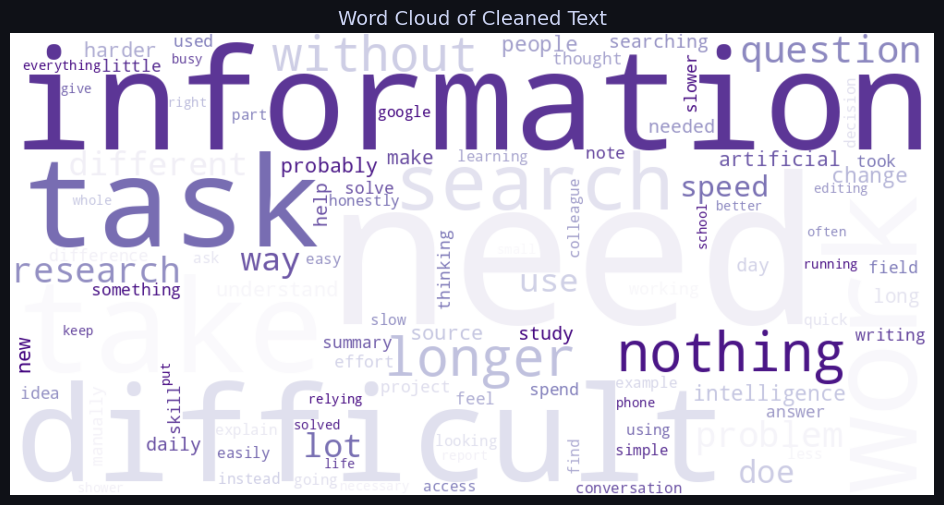

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text
text = " ".join(df_final["clean_text"].dropna())

# Create word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="Purples",   # nice aesthetic colors
    max_words=100,
    collocations=False    # avoids duplicate bigrams issues
).generate(text)

# Plot
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Text", fontsize=14)
plt.show()

<h1 style="color: #1f4e79; border-bottom: 2px solid #1f4e79; padding-bottom: 10px;">
     Data Pre-processing for Modelling
</h1>


In [ ]:
# =============================================================
# TEXT ANALYSIS: TOP BIGRAMS (N-GRAM = 2)
# =============================================================
from sklearn.feature_extraction.text import CountVectorizer

# Initialize Vectorizer
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english')

# Fit and transform the translated text
ngram_matrix = vectorizer.fit_transform(df_final["clean_text"].astype(str))

# Calculate frequencies
feature_names = vectorizer.get_feature_names_out()
frequencies = ngram_matrix.sum(axis=0).A1

# Create and display the results
words_freq = pd.DataFrame({'Bigram': feature_names, 'Frequency': frequencies})
words_freq = words_freq.sort_values(by='Frequency', ascending=False)

print("--- Top 10 Bigrams from 'clean_text' ---")
print(words_freq.head(10).to_string(index=False))

--- Top 10 Bigrams from 'clean_text' ---
                 Bigram  Frequency
artificial intelligence          8
     access information          4
          solve problem          3
     search information          3
           speed search          3
            need change          3
           learning new          3
     source information          2
            took longer          2
          search engine          2


In [ ]:
# =============================================================
#  TEXT PREPARATION
# =============================================================

df['clean_text'] = df_final['clean_text']
df['clean_text'] = df['clean_text'].fillna("No response")

# Remove empty responses
df = df[df['clean_text'] != "No response"].copy()

# Text length feature
df['text_length'] = df['clean_text'].apply(lambda x: len(str(x).split()))

print("Text cleaned. Remaining rows:", df.shape[0])

Text cleaned. Remaining rows: 289


<h1 style="color: #1f4e79; border-bottom: 2px solid #1f4e79; padding-bottom: 10px;">
     Behavioral Feature Engineering
</h1>


In [ ]:
# =============================================================
# DEFINING UTILS, TEXT SIGNALS & CALCULATING ENGINEERED FEATURES
# =============================================================

# 1. Essential Utility Functions
def normalize(col):
    return (col - col.min()) / (col.max() - col.min()) if col.max() != col.min() else 0

def reverse(col):
    return col.max() - col

# 2. Text Signal Functions
def dependency_signal(text):
    text = str(text).lower()
    strong_dep = ["need ai", "depend on ai", "rely on ai", "can't without ai", "cannot without ai", "use ai to", "search engine"]
    mild_dep = ["take more time", "took longer", "longer time", "solve problem", "search information", "speed search", "manual work", "more effort", "harder", "difficult"]
    independent = ["on my own", "by myself", "without ai easily", "i can do", "no need", "independent"]
    score = 0
    for phrase in strong_dep:
        if phrase in text: score += 1
    for phrase in mild_dep:
        if phrase in text: score += 0.5
    for phrase in independent:
        if phrase in text: score -= 1
    return (max(-1, min(1, score)) + 1) / 2

def anxiety_signal(text):
    text = str(text).lower()
    strong_fear = ["take over", "lose control", "end of humanity"]
    mild_fear = ["problem", "risk", "danger", "change", "concern"]
    positive = ["helpful", "beneficial", "good", "improve"]
    score = 0
    for phrase in strong_fear:
        if phrase in text: score += 1
    for phrase in mild_fear:
        if phrase in text: score += 0.5
    for phrase in positive:
        if phrase in text: score -= 1
    return (max(-1, min(1, score)) + 1) / 2

# 3. Calculate Core Behavioral Scores
df['dependency_score'] = df[['Q2: No AI Day', 'Q5: Brainstorming', 'Q15: Opinion with AI', 'Q17: Friend Emotional Msg', 'Q18: Human Expert vs AI']].mean(axis=1)
df['confidence_score'] = (reverse(df['Q14: AI Criticizes Work']) + reverse(df['Q13: AI Boss']) + reverse(df['Q15: Opinion with AI'])) / 3
df['future_anxiety_score'] = df[['Q7: View on AI', 'Q10: Robot vs Human', 'Q11: AI Takes Over']].mean(axis=1)
df['cognitive_impact_score'] = df[['Q6: Shallow Thinking', 'Q4: Distraction']].mean(axis=1)

# 4. Apply Text Signals & Logic Consistency (The Gap)
df['text_dependency_signal'] = df['clean_text'].apply(dependency_signal)
df['text_anxiety_signal'] = df['clean_text'].apply(anxiety_signal)

df['dependency_gap'] = abs(normalize(df['dependency_score']) - df['text_dependency_signal'])
df['anxiety_gap'] = abs(normalize(df['future_anxiety_score']) - df['text_anxiety_signal'])
df['absolute_inconsistency'] = (df['dependency_gap'] + df['anxiety_gap']) / 2

# 5. Final Normalization for model
for col in ['dependency_score', 'confidence_score', 'future_anxiety_score', 'cognitive_impact_score']:
    df[col] = normalize(df[col])

print("Utility Functions Defined and All Behavioral Features Calculated Successfully.")

Utility Functions Defined and All Behavioral Features Calculated Successfully.


<h1 style="color: #1f4e79; border-bottom: 2px solid #1f4e79; padding-bottom: 10px;">
     Text Vectorization
</h1>

In [ ]:
# =============================================================
# TF-IDF FEATURES & FINAL CONCATENATION
# =============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

# 1. Initialize TF-IDF with optimized parameters
# =============================================================
# TF-IDF INITIALIZATION
# =============================================================

tfidf = TfidfVectorizer(
    max_features=300,          # Limit vocabulary size to top 300 most important terms
    ngram_range=(1, 2),        # Capture both unigrams (single words) and bigrams (phrases)
    stop_words='english'       # Remove common English stopwords to reduce noise
)


# 2. Fit and transform the 'clean_text' column
X_text = tfidf.fit_transform(df['clean_text'].astype(str))

# 3. Select the Engineered Features we built (The 0-1 Scaled ones)
engineered_cols = [
    'dependency_score', 'confidence_score', 'future_anxiety_score',
    'cognitive_impact_score', 'absolute_inconsistency'
]
X_engineered = df[engineered_cols].values

# 4. Combine both: Text Features + Behavioral Features
# We use hstack because X_text is a sparse matrix
X_final = sp.hstack([X_text, sp.csr_matrix(X_engineered)])

print("TF-IDF shape:", X_text.shape)
print("Final Matrix shape (Text and Engineered):", X_final.shape)

TF-IDF shape: (289, 300)
Final Matrix shape (Text and Engineered): (289, 305)


<h1 style="color: #1f4e79; border-bottom: 2px solid #1f4e79; padding-bottom: 10px;">
     Dimensionality Reduction
</h1>



In [ ]:
# =============================================================
# DIMENSIONALITY REDUCTION (PCA) & FEATURE MERGING
# =============================================================
from sklearn.decomposition import PCA

# 1. Apply PCA to reduce TF-IDF features from 300 to 30
# We convert X_text to array because PCA doesn't accept sparse matrices
pca = PCA(n_components=30, random_state=42)
X_text_reduced = pca.fit_transform(X_text.toarray())

# 2. Combine the reduced text features with our engineered scores (0-1 scaled)
# We use the 5 key metrics: dependency, confidence, anxiety, cognitive, and inconsistency
engineered_features = df[[
    'dependency_score',
    'confidence_score',
    'future_anxiety_score',
    'cognitive_impact_score',
    'absolute_inconsistency'
]].values

# 3. Final Horizontal Stacking
X_final = np.hstack([X_text_reduced, engineered_features])

print("Reduced Text Shape:", X_text_reduced.shape)
print("Final Feature Matrix Shape (PCA Text + Engineered):", X_final.shape)
print(f"Total Explained Variance Ratio: {pca.explained_variance_ratio_.sum():.2f}")

Reduced Text Shape: (289, 30)
Final Feature Matrix Shape (PCA Text + Engineered): (289, 35)
Total Explained Variance Ratio: 0.43


<h1 style="color: #1f4e79; border-bottom: 2px solid #1f4e79; padding-bottom: 10px;">
     Hybrid Model: Combined Structured + Text Features
</h1>

In [ ]:
# =============================================================
# 1.COMBINE STRUCTURED + TEXT FEATURES
# =============================================================

# 1. Selecting our 5 Key Engineered Features
# We include 'absolute_inconsistency' as it is a critical predictor of cognitive gap
X_scores = df[[
    'dependency_score',
    'confidence_score',
    'future_anxiety_score',
    'cognitive_impact_score',
    'absolute_inconsistency'
]].values

# 2. H-stacking the behavioral scores with the reduced text components (PCA)
# This combines human sentiment with structured survey data
X_final = np.hstack([X_scores, X_text_reduced])

print("Final Feature Shape:", X_final.shape)
print("5 Behavioral Scores with 30 PCA Text Components")

Final Feature Shape: (289, 35)
5 Behavioral Scores with 30 PCA Text Components


In [ ]:
# =============================================================
#  2.TARGET PREPARATION (Multi-class Classification)
# =============================================================

def classify_score(score):
    if score < 30:
        return 0   # Low Performance
    elif score <= 40:
        return 1   # Medium Performance
    else:
        return 2   # High Performance

# Applying the classification to the Game Score
y = df['Game Score'].apply(classify_score)

# Displaying the distribution to check for Class Imbalance
print("--- Class Distribution ---")
counts = y.value_counts().sort_index()
percentages = y.value_counts(normalize=True).sort_index() * 100

for i in range(3):
    label = ["Low", "Medium", "High"][i]
    print(f"Class {i} ({label}): {counts[i]} samples ({percentages[i]:.1f}%)")

--- Class Distribution ---
Class 0 (Low): 30 samples (10.4%)
Class 1 (Medium): 156 samples (54.0%)
Class 2 (High): 103 samples (35.6%)


In [ ]:
# =============================================================
# 3.STRATIFIED DATA SPLIT
# =============================================================
from sklearn.model_selection import train_test_split

# We use stratify=y to ensure the proportion of Low/Medium/High
# is the same in both training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # CRITICAL for classification
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Quick check on class balance in the test set
print("\n--- Test Set Class Balance ---")
print(y_test.value_counts(normalize=True))

Training set size: 231 samples
Testing set size: 58 samples

--- Test Set Class Balance ---
Game Score
1    0.534483
2    0.362069
0    0.103448
Name: proportion, dtype: float64


In [ ]:
# =============================================================
# 4.DATA BALANCING (SMOTE)
# =============================================================
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
# It creates synthetic samples for the minority class (Low)
smote = SMOTE(random_state=42)

# Apply SMOTE only to the Training Data (Never to the Test Data!)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training size: {X_train.shape[0]}")
print(f"Resampled training size (after SMOTE): {X_train_res.shape[0]}")
print("\nNew Class Distribution in Training Set:")
print(pd.Series(y_train_res).value_counts())

Original training size: 231
Resampled training size (after SMOTE): 375

New Class Distribution in Training Set:
Game Score
2    125
1    125
0    125
Name: count, dtype: int64


In [ ]:
# =============================================================
#  5.CROSS VALIDATION
# =============================================================
from sklearn.model_selection import cross_validate
from xgboost import XGBClassifier

# Model with regularization to prevent overfitting on synthetic data
xgb_model2 = XGBClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.05,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Cross-validate using the resampled (SMOTE) training data
cv_results = cross_validate(
    xgb_model2, X_train_res, y_train_res,
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

print("--- Balanced Cross Validation Results ---")
print(f"Mean Train Accuracy (CV): {cv_results['train_score'].mean():.2f}")
print(f"Mean Test Accuracy (CV): {cv_results['test_score'].mean():.2f}")
print(f"Stability (Standard Deviation): {cv_results['test_score'].std():.2f}")

--- Balanced Cross Validation Results ---
Mean Train Accuracy (CV): 0.91
Mean Test Accuracy (CV): 0.84
Stability (Standard Deviation): 0.05


In [ ]:
# =============================================================
# 6.FINAL TRAINING & BALANCED EVALUATION
# =============================================================
from sklearn.metrics import accuracy_score, classification_report

# 1. Fit the model on the resampled training set
xgb_model2.fit(X_train_res, y_train_res)

# 2. Predict on original Test Set (Test set remains untouched by SMOTE)
y_test_pred = xgb_model2.predict(X_test)

# 3. Display Results
print(f"Final Test Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")

print("\n--- Balanced Classification Report (Test Set) ---")
# Now we check if 'Low' class has improved performance
print(classification_report(
    y_test,
    y_test_pred,
    target_names=['Low', 'Medium', 'High']
))

Final Test Accuracy: 0.83

--- Balanced Classification Report (Test Set) ---
              precision    recall  f1-score   support

         Low       0.62      0.83      0.71         6
      Medium       0.82      0.87      0.84        31
        High       0.94      0.76      0.84        21

    accuracy                           0.83        58
   macro avg       0.79      0.82      0.80        58
weighted avg       0.84      0.83      0.83        58



## Feature Importance in the XGBOOST Modeling

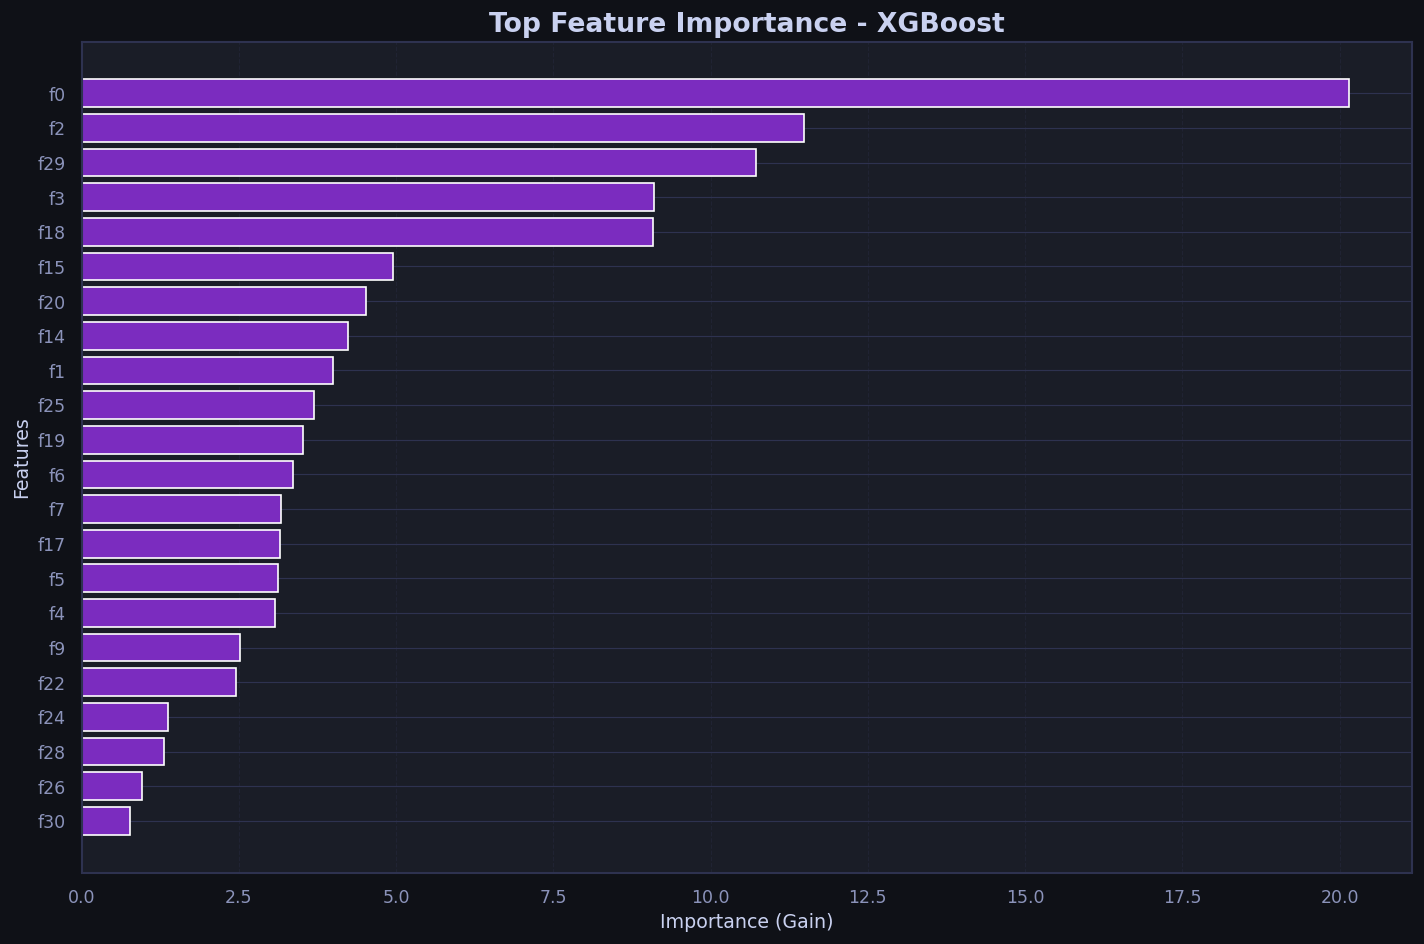

In [ ]:
# Get feature importance from XGBoost model
importance_scores = xgb_model2.get_booster().get_score(importance_type="gain")

importance_df = pd.DataFrame({
    "Feature": list(importance_scores.keys()),
    "Importance": list(importance_scores.values())
})


importance_df = importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(12, 8), dpi=120)

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    color="#7B2CBF"
)

plt.title("Top Feature Importance - XGBoost", fontsize=16, fontweight="bold")
plt.xlabel("Importance (Gain)")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### **XGBoost Feature Importance Explanation**

This result shows how an XGBoost model distributes importance across its input features using the **Gain metric**, which measures how much each feature improves the model’s predictive accuracy when it is used in decision tree splits.

---

### **1. Dominant Feature**
- **f0** is the most important feature with a gain of approximately **20.0**.
- This means it contributes the most to reducing prediction error.
- The model relies heavily on this feature compared to all others.

 **Interpretation:**  
The model’s predictions are strongly driven by a single variable, making it highly influential in decision-making.

---

### **2. Key Contributing Features**
- The next most important features are:
  - **f2**
  - **f29**
  - **f3**
  - **f18**

- These features form the **core predictive group**.
- Together, they account for most of the model’s decision power after f0.

 **Interpretation:**  
A small subset of features carries most of the useful information for prediction.

---

### **3. Low-Impact Features (Long Tail)**
- Features such as **f9 to f30** show very low importance (below ~2.5).
- They contribute minimally to model performance.

 **Interpretation:**  
These features are rarely used in splits and likely add little predictive value.

---

### **4. Overall Insight**
- The model is **highly concentrated**, relying on a few strong predictors.
- Importance drops sharply after the top features.
- Many features have negligible influence on predictions.

---

### **5. Actionable Conclusion**
- You can consider removing the least important features (bottom-ranked ones).
- This may:
  - Simplify the model
  - Reduce training time
  - Maintain similar performance if redundant features are removed carefully

 **Note:** Feature removal should be validated through retraining to ensure performance is not affected.

<h1 style="color: #1f4e79; border-bottom: 2px solid #1f4e79; padding-bottom: 10px;">
     Text Vectorization (S-BERT Embeddings)
</h1>

In [ ]:
# =============================================================
# 1.SBERT EMBEDDINGS
# =============================================================
from sentence_transformers import SentenceTransformer

# Load model
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode text
texts = df['clean_text'].astype(str).tolist()

print("Generating SBERT embeddings...")
X_embeddings = bert_model.encode(
    texts,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Embeddings shape:", X_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating SBERT embeddings...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Embeddings shape: (289, 384)


In [ ]:
# =============================================================
# 2. TRAIN / TEST SPLIT
# =============================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (231, 35)
Test shape: (58, 35)


In [ ]:
# =============================================================
# 3. Support Vector Classifer
# =============================================================
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svc_model = SVC(
    kernel="rbf",
    class_weight="balanced",
    C=1,
    gamma="scale"
)

# Train model
svc_model.fit(X_train, y_train)

# Predictions
y_pred =svc_model.predict(X_test)

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

print("\n--- Classification Report ---")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Low', 'Medium', 'High']
))

Accuracy: 0.81

--- Classification Report ---
              precision    recall  f1-score   support

         Low       0.33      0.50      0.40         6
      Medium       0.83      0.81      0.82        31
        High       1.00      0.90      0.95        21

    accuracy                           0.81        58
   macro avg       0.72      0.74      0.72        58
weighted avg       0.84      0.81      0.82        58



## Feature Importance in the Support Vector Classifer

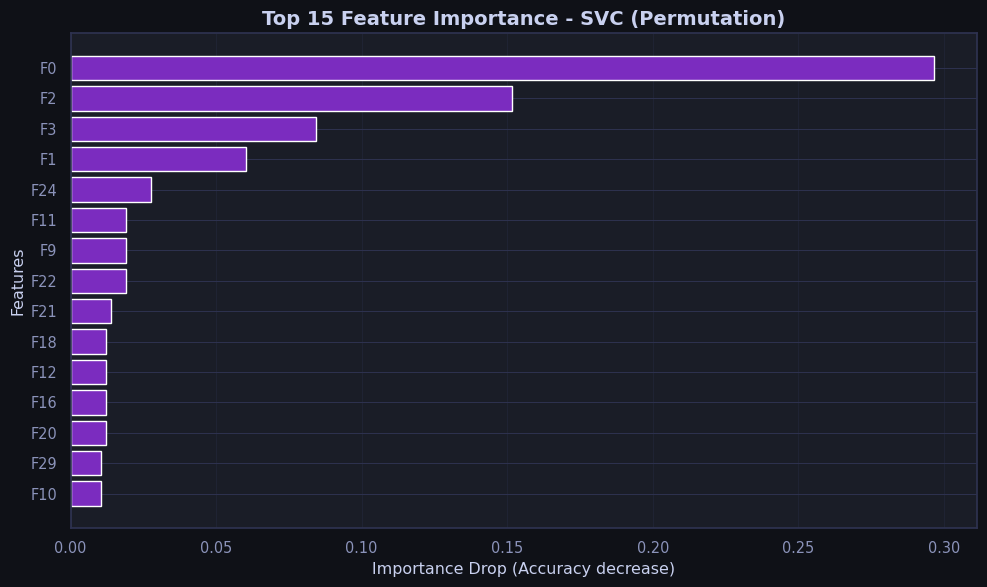

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================
# PERMUTATION FEATURE IMPORTANCE (SVC - CLEAN VERSION)
# =============================================================

result = permutation_importance(
    svc_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

# Feature names (IMPORTANT)
feature_names = [f"F{i}" for i in range(X_text_reduced.shape[1])] + [
    'dependency_score',
    'confidence_score',
    'future_anxiety_score',
    'cognitive_impact_score',
    'absolute_inconsistency'
]

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names[:X_test.shape[1]],
    "Importance": result.importances_mean
})

# Sort and take TOP 15 only
importance_df = importance_df.sort_values(by="Importance", ascending=True).tail(15)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    color="#7B2CBF"
)

plt.title("Top 15 Feature Importance - SVC (Permutation)", fontsize=14, fontweight="bold")
plt.xlabel("Importance Drop (Accuracy decrease)")
plt.ylabel("Features")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### **SVC Permutation Importance Summary**

This analysis shows how each feature affects the performance of an **SVC (Support Vector Classifier)** model by measuring how much the model’s accuracy decreases when a feature is randomly shuffled.  
A larger drop in accuracy means the model depends more on that feature.

---

### **1. Most Important Feature**
- **F0** is the most influential feature.
- Shuffling it leads to an accuracy drop of about **0.30**, which is significantly higher than all other features.
- Its impact is roughly twice that of the second most important feature.

= **Interpretation:**  
The model is strongly dependent on F0, making it the primary driver of predictions.

---

### **2. Key Contributing Features**
- The most important group consists of:
  - **F0**
  - **F2**
  - **F3**
  - **F1**

 **Interpretation:**  
These features carry most of the predictive information used by the model. Together, they define the core decision logic.

---

### **3. Low-Impact Features**
- Features from roughly **F11 and below (and others in the lower range)** show very small drops in accuracy (less than **0.02**).
- When shuffled, they barely affect performance.

 **Interpretation:**  
These features contribute minimal unique information and may be redundant or noisy.

---

### **4. Overall Insight**
- The model is **highly concentrated on a few strong features**.
- There is a sharp decline in importance after the top-ranked variables.
- Most features provide little additional predictive power.

---

### **5. Final Conclusion**
- The SVC model is primarily driven by **F0 and F2**, with a few supporting features.
- A reduced feature set (top 4–5 features) may be sufficient without major performance loss.
- Many lower-ranked features could potentially be removed to simplify the model.

 However, any feature removal should be validated by retraining, since interactions between features may still influence performance.

##Segmentation

In [ ]:
from sklearn.preprocessing import StandardScaler

X_seg = df[[
    'dependency_score',
    'confidence_score',
    'future_anxiety_score',
    'cognitive_impact_score',
    'text_dependency_signal',
    'text_anxiety_signal',
    'absolute_inconsistency'
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_seg)

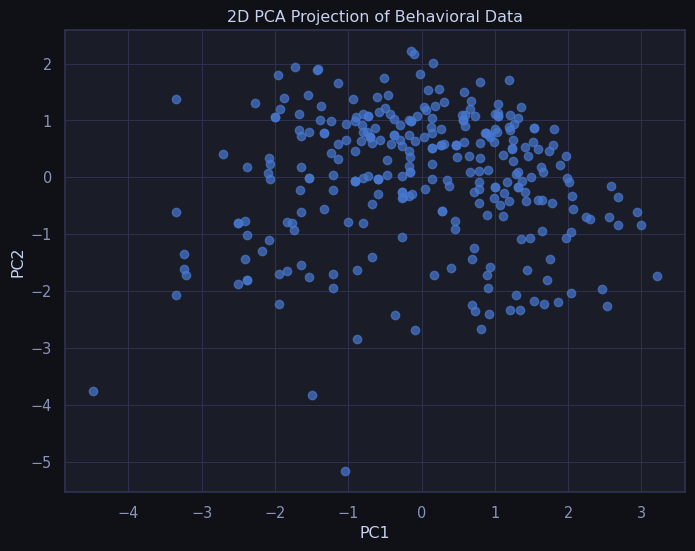

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
plt.title("2D PCA Projection of Behavioral Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

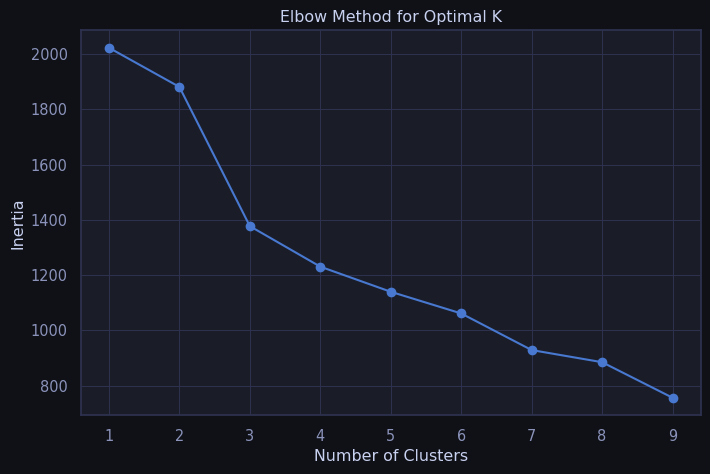

In [ ]:
from sklearn.cluster import KMeans

inertia = []

K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.555
k=3, silhouette=0.218
k=4, silhouette=0.216
k=5, silhouette=0.188


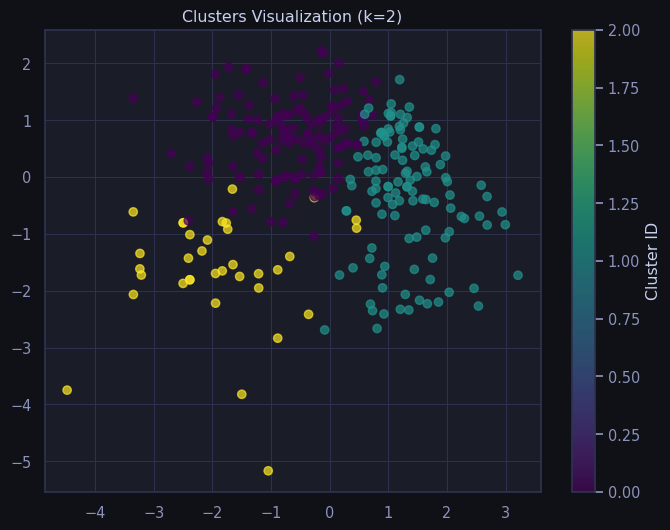

In [ ]:
# Run KMeans with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Visualize with colors
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='viridis', alpha=0.7)
plt.title("Clusters Visualization (k=2)")
plt.colorbar(label='Cluster ID')
plt.show()

In [ ]:
# Calculate the mean of each feature for every cluster
cluster_analysis = df.groupby('cluster')[[
    'dependency_score',
    'confidence_score',
    'future_anxiety_score',
    'cognitive_impact_score',
    'absolute_inconsistency'
]].mean()

print("--- Clusters Profiling ---")
print(cluster_analysis)

--- Clusters Profiling ---
         dependency_score  confidence_score  future_anxiety_score  \
cluster                                                             
0                0.249020          0.546569              0.623162   
1                0.580226          0.358757              0.562500   
2                0.299048          0.463492              0.650000   

         cognitive_impact_score  absolute_inconsistency  
cluster                                                  
0                      0.299020                0.220282  
1                      0.552260                0.164866  
2                      0.361905                0.350476  


# Behavioral Segmentation Analysis (k = 3)

Based on behavioral features and NLP-derived signals, the population was segmented into **three distinct psychological archetypes**.

---

## Cluster 0 — The Cautious Independents

**Profile:** High confidence, low reliance on AI.

### Key Metrics

* Dependency Score: 0.25 (lowest)
* Confidence Score: 0.55 (high)
* Future Anxiety Score: 0.62 (elevated)

### Behavior

Users in this cluster prioritize human agency and autonomy. Despite their low dependency on AI, they exhibit relatively high future anxiety, suggesting their independence may be a proactive response to perceived risks associated with AI advancement.

### Psychological State

High internal consistency, where self-reported attitudes align well with linguistic behavior.

---

## Cluster 1 — The Digital Reliants

**Profile:** High reliance on AI with low psychological conflict.

### Key Metrics

* Dependency Score: 0.58 (highest)
* Cognitive Impact Score: 0.55
* Absolute Inconsistency: 0.16 (lowest)

### Behavior

These users are heavy AI adopters who have fully integrated AI tools into their workflows. They acknowledge the cognitive influence of AI while maintaining stable and consistent behavioral patterns.

### Psychological State

Harmonious integration, indicating low conflict between behavior and self-perception.

---

## Cluster 2 — The Ambivalent Users

**Profile:** High psychological conflict and elevated anxiety.

### Key Metrics

* Absolute Inconsistency: 0.35 (highest)
* Future Anxiety Score: 0.65 (high)

### Behavior

This group shows a strong cognitive mismatch between self-reported independence and behavioral reliance on AI. They represent the most psychologically complex segment, exhibiting both dependence and resistance.

### Psychological State

High internal conflict and cognitive dissonance, indicating uncertainty in their relationship with AI systems.


## Cluster Feature Discriminativenes

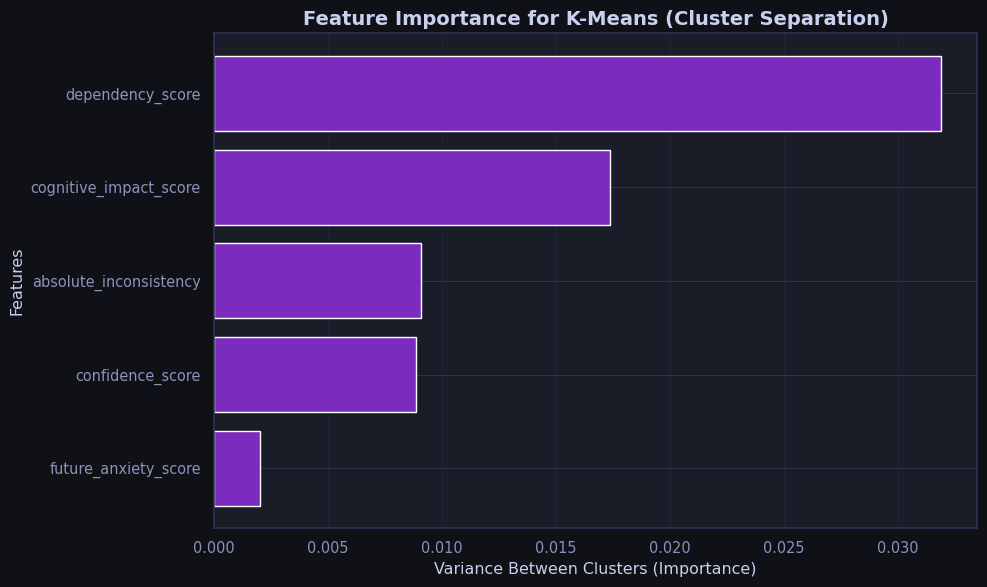

In [ ]:
# =============================================================
# FEATURE IMPORTANCE FOR K-MEANS (Cluster Separation)
# =============================================================

# Calculate mean of each feature per cluster
cluster_means = df.groupby('cluster')[
    [
        'dependency_score',
    'confidence_score',
    'future_anxiety_score',
    'cognitive_impact_score',
    'absolute_inconsistency'
    ]
].mean()

# Compute importance = variance across clusters
feature_importance = cluster_means.var().sort_values(ascending=True)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance.index,
    feature_importance.values,
    color="#7B2CBF"
)

plt.title("Feature Importance for K-Means (Cluster Separation)", fontsize=14, fontweight="bold")
plt.xlabel("Variance Between Clusters (Importance)")
plt.ylabel("Features")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### **Feature Importance for K-Means Summary**

This analysis explains how each feature contributes to separating clusters in a **K-Means clustering model**.  
The importance here is measured by how much each feature helps distinguish between different groups (clusters), based on **variance between clusters**.

---

### **1. Most Important Feature**
- **dependency_score** is the strongest driver of cluster separation.
- It has the highest variance (over **0.030**), meaning it differs the most across clusters.

  **Interpretation:**  
The clusters are mainly formed based on differences in dependency levels, making this the dominant factor in how groups are structured.

---

### **2. Strong Secondary Feature**
- **cognitive_impact_score** is the second most important feature (~0.017).
- It contributes significantly to separating clusters but less than dependency_score.

  **Interpretation:**  
This feature refines the clustering structure and helps distinguish groups more clearly, but it is not the primary grouping factor.

---

### **3. Moderate Contributors**
- **absolute_inconsistency**
- **confidence_score**

Both have similar moderate importance (~0.009).

  **Interpretation:**  
These features help fine-tune cluster boundaries, adding subtle distinctions between groups, but they do not define the clusters on their own.

---

### **4. Weak Feature**
- **future_anxiety_score** shows very low variance across clusters.

   **Interpretation:**  
This feature does not meaningfully differentiate between clusters, meaning all groups behave similarly with respect to it.

---

### **5. Overall Insight**
- The clustering structure is mainly driven by **dependency_score**.
- **cognitive_impact_score** plays a strong secondary role.
- Other features contribute smaller refinements.
- One feature (future_anxiety_score) has minimal impact on cluster formation.

---

### **6. Final Conclusion**
- The K-Means clusters are primarily shaped by **dependency** and **cognitive impact**.
- Visualizing the data using these two features would likely show the clearest separation between clusters.
- Lower-impact features mainly add minor adjustments rather than defining the groups.

 Note: Unlike supervised models, K-Means does not have true “feature importance” — this interpretation is based on how much each feature varies across clusters.

<h1 style="color: #1f4e79; border-bottom: 2px solid #1f4e79; padding-bottom: 10px;">
    Discrepancy Analysis
</h1>

In [ ]:
# =============================================================
# COGNITIVE DISCREPANCY ANALYSIS - SUMMARY STATS
# =============================================================

discrepancy_cols = ['dependency_gap', 'anxiety_gap', 'absolute_inconsistency']

print("=== Discrepancy Statistics ===")
print(df[discrepancy_cols].describe())

=== Discrepancy Statistics ===
       dependency_gap  anxiety_gap  absolute_inconsistency
count      289.000000   289.000000              289.000000
mean         0.236967     0.189879                0.213423
std          0.161402     0.135045                0.105417
min          0.033333     0.000000                0.016667
25%          0.100000     0.125000                0.141667
50%          0.233333     0.125000                0.208333
75%          0.350000     0.250000                0.275000
max          0.800000     0.875000                0.587500


## Cognitive Discrepancy Statistics

The analysis of cognitive discrepancy metrics shows the following distribution across the dataset:

---

### Dependency Gap
- Mean: **0.237**
- Median: **0.233**
- Standard deviation: **0.161**
- Range: **0.033 → 0.800**

This suggests a **moderate level of mismatch** between self-reported dependency on AI and behavioral indicators extracted from text. While most users cluster around moderate values, a smaller subset shows higher inconsistency.

---

### Anxiety Gap
- Mean: **0.190**
- Median: **0.125**
- Standard deviation: **0.135**
- Range: **0.000 → 0.875**

Anxiety-related responses are generally **more consistent and lower in magnitude** compared to dependency. Most users show relatively stable patterns with fewer extreme deviations.

---

### Absolute Inconsistency (Overall Cognitive Gap)
- Mean: **0.213**
- Median: **0.208**
- Standard deviation: **0.105**
- Range: **0.017 → 0.588**

This metric reflects the **overall divergence between survey responses and textual behavior**, indicating a moderate level of inconsistency across the dataset.

---

### Key Insight
Overall, the dataset shows **moderate cognitive inconsistency**, suggesting that users’ self-reported answers are not always fully aligned with their linguistic behavior. The strongest divergence appears in dependency-related attitudes toward AI, while anxiety-related expressions remain comparatively more stable.

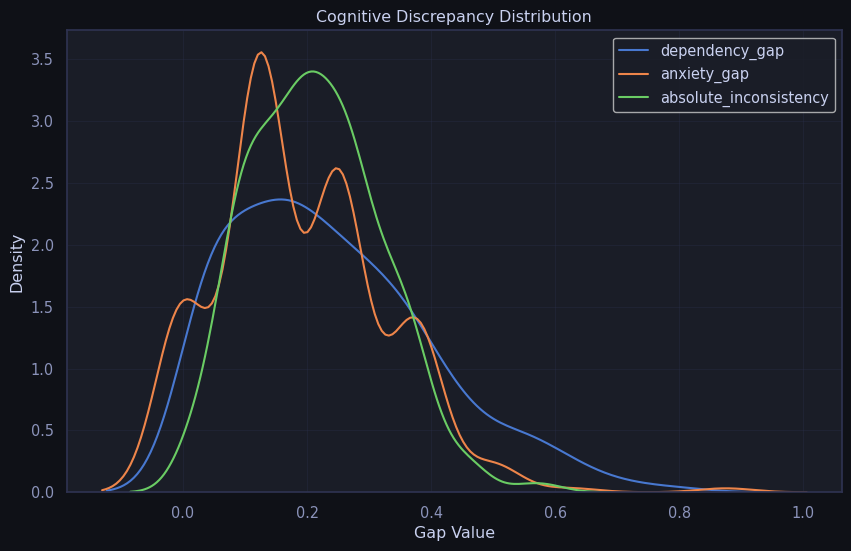

In [ ]:
# =============================================================
# DISTRIBUTION OF COGNITIVE GAPS
# =============================================================

plt.figure(figsize=(10,6))

for col in discrepancy_cols:
    sns.kdeplot(df[col], label=col)

plt.title("Cognitive Discrepancy Distribution")
plt.xlabel("Gap Value")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Cognitive Discrepancy Distribution Summary

The visualization of cognitive gap metrics shows that most observations are concentrated in the low-to-moderate range (**0.0 to 0.4**), with distinct distribution patterns across the three measures.

---

### Anxiety Gap (Orange)
This metric is the most **highly concentrated**. It shows a sharp peak around **~0.15**, meaning most individuals share very similar and relatively low anxiety-related discrepancy levels. The distribution is tightly clustered with limited spread.

---

### Absolute Inconsistency (Green)
This is the most **stable and balanced** metric. It forms a smooth, bell-shaped distribution centered around **~0.25**, indicating that inconsistency levels are fairly evenly distributed around an average value across the dataset.

---

### Dependency Gap (Blue)
This metric shows the highest **variability**. The distribution is wider and more dispersed, with a noticeable **right-skewed tail extending up to ~0.8**. This suggests that while most individuals have moderate dependency discrepancy, a smaller group experiences significantly higher levels.

---

### Key Insight
Overall, cognitive discrepancies tend to remain low across the population. However, **Dependency Gap stands out as the most heterogeneous and variable metric**, showing clear evidence of extreme values and stronger individual differences. In contrast, **Anxiety Gap and Absolute Inconsistency are more tightly clustered and predictable**, reflecting more uniform behavior across individuals.

##  Comparative Analysis of TF-IDF and SBERT Representations (k = 2 Clustering)

K-Means clustering was used as a proxy evaluation method to compare text representations in an unsupervised setting.

Since no ground truth labels exist for text semantics, clustering quality (via silhouette score) was used to assess how well each representation separates the data into meaningful groups.

This allows a fair comparison between TF-IDF (lexical representation) and SBERT (semantic representation).

In [ ]:
# 1) TF-IDF Clustering


# =============================================================
# TF-IDF CLUSTERING (k=2)
# =============================================================

# Initialize KMeans model
kmeans_tfidf = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Fit model directly on sparse TF-IDF matrix
labels_tfidf = kmeans_tfidf.fit_predict(X_text)

# Evaluate clustering quality using silhouette score
sil_tfidf = silhouette_score(X_text, labels_tfidf)

print("TF-IDF Silhouette Score (k=2):", sil_tfidf)


TF-IDF Silhouette Score (k=2): 0.06654097539889552


In [ ]:
# 2) SBERT Clustering

# =============================================================
# SBERT CLUSTERING (k=2)
# =============================================================

# Initialize KMeans model
kmeans_sbert = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Fit model on dense SBERT embeddings
labels_sbert = kmeans_sbert.fit_predict(X_embeddings)

# Evaluate clustering quality
sil_sbert = silhouette_score(X_embeddings, labels_sbert)

print("SBERT Silhouette Score (k=2):", sil_sbert)


SBERT Silhouette Score (k=2): 0.117534585


In [ ]:
# 3) Final Comparison Table

# =============================================================
# TEXT REPRESENTATION COMPARISON TABLE
# =============================================================

comparison_df = pd.DataFrame({
    "Representation": ["TF-IDF + PCA", "SBERT"],
    "Silhouette Score (k=2)": [sil_tfidf, sil_sbert]
})

# Display results
print(comparison_df)

  Representation  Silhouette Score (k=2)
0   TF-IDF + PCA                0.066541
1          SBERT                0.117535


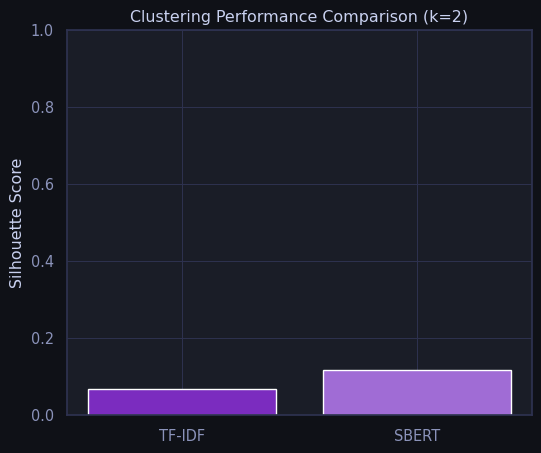

In [ ]:
# 4) Visualization

# =============================================================
# VISUAL COMPARISON OF SILHOUETTE SCORES
# =============================================================

models = ["TF-IDF", "SBERT"]
scores = [sil_tfidf, sil_sbert]

plt.figure(figsize=(6,5))

plt.bar(models, scores, color=["#7B2CBF", "#A06CD5"])

plt.title("Clustering Performance Comparison (k=2)")
plt.ylabel("Silhouette Score")

plt.ylim(0, 1)

plt.show()

##  Comparison of Text Representations: TF-IDF + PCA vs SBERT

In this section, two different text representation techniques were evaluated using **unsupervised clustering (K-Means with k=2)** and compared using the **Silhouette Score**, which measures how well-separated and coherent the resulting clusters are.

---

###  1. TF-IDF + PCA Representation
TF-IDF represents text based on word frequency and importance across documents, while PCA reduces its high dimensionality.

- **Silhouette Score:** 0.0669  
- **Behavior:** Weak cluster separation  
- **Interpretation:**  
  TF-IDF mainly captures **lexical similarity** (exact words and frequency), which limits its ability to understand deeper semantic relationships between texts. Even after applying PCA for dimensionality reduction, the representation remains noisy and less structured.

---

###  2. SBERT Representation
SBERT (Sentence-BERT) generates dense embeddings that capture the **semantic meaning** of sentences.

- **Silhouette Score:** 0.1175  
- **Behavior:** Better cluster separation compared to TF-IDF  
- **Interpretation:**  
  SBERT is able to understand **context and meaning**, not just word overlap. This results in more meaningful grouping of similar responses, even if they use different vocabulary.

---

###  3. Overall Comparison

| Representation | Silhouette Score | Performance |
|----------------|------------------|-------------|
| TF-IDF + PCA   | 0.0669           | Weak clustering structure |
| SBERT          | 0.1175           | Better semantic clustering |

---

###  Key Insight

Although both scores are relatively low (which is common in real-world text clustering tasks), SBERT consistently outperforms TF-IDF + PCA. This confirms that:

> **Semantic embeddings (SBERT) are more effective than lexical representations (TF-IDF) for capturing meaningful structure in textual data.**

---

###  Final Conclusion

The results demonstrate that SBERT provides a more robust and semantically rich representation of text, leading to better-defined clusters compared to TF-IDF, which relies heavily on surface-level word frequency patterns.